# Transfer Learning for CIC-IDS



## 1 · Install Dependencies

In [5]:
import subprocess, sys
pkgs = [
    'torch>=2.0.0', 'torchvision>=0.15.0',
    'numpy>=1.23.0', 'pandas>=1.5.0',
    'scikit-learn>=1.2.0', 'opencv-python-headless>=4.7.0',
    'matplotlib>=3.6.0', 'seaborn>=0.12.0',
    'scipy>=1.9.0', 'tqdm>=4.65.0',
    'imbalanced-learn>=0.11.0',  # for BorderlineSMOTE
]
subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *pkgs])
print('All packages ready ✓')

All packages ready ✓


## 2 · Imports & Device

In [9]:
import os, glob, math, json, pickle, warnings, copy, gc, shutil
from pathlib import Path
from typing import Dict, List, Optional, Tuple

import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from tqdm.auto import tqdm
from scipy.stats import mode as scipy_mode
from collections import Counter

from sklearn.preprocessing import QuantileTransformer, label_binarize
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    confusion_matrix, roc_curve, auc, matthews_corrcoef
)

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler, Subset
from torch.optim.lr_scheduler import ReduceLROnPlateau
import torchvision.transforms as T
import torchvision.models as tv_models
import torchvision.datasets as tv_datasets

warnings.filterwarnings('ignore')
%matplotlib inline

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device : {DEVICE}')
if DEVICE == 'cuda':
    print(f'GPU    : {torch.cuda.get_device_name(0)}')
    print(f'VRAM   : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

Device : cuda
GPU    : Tesla P100-PCIE-16GB
VRAM   : 17.1 GB


## 3 · Configuration



In [ ]:
# Defining Paths
TRAIN_DATA_DIR = '/kaggle/input/datasets/chethuhn/network-intrusion-dataset'  # 2017 → train
TEST_DATA_DIR  = '/kaggle/input/datasets/solarmainframe/ids-intrusion-csv'    # 2018 → test
IMG_TRAIN_DIR  = '/kaggle/working/images_2017/'
IMG_TEST_DIR   = '/kaggle/working/images_2018/' 
MODEL_SAVE_DIR = '/kaggle/working/saved_models/'
RESULTS_DIR    = '/kaggle/working/results/'

os.makedirs(MODEL_SAVE_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR,    exist_ok=True)

# Image generation
N_FEATURES     = 64          # features kept
ROWS_PER_IMAGE = 192         # 64 features × 3 channels 
OUTPUT_IMG_SIZE = 299        

# Training 
BATCH_SIZE      = 64         
EPOCHS_FROZEN   = 5          
EPOCHS_FINE     = 10         
LR_FROZEN       = 1e-4
LR_FINE         = 1e-5
DROPOUT_RATE    = 0.5
WEIGHT_DECAY    = 1e-4
PATIENCE        = 3
RANDOM_SEED     = 42
NUM_WORKERS     = 4          

# Models
CNN_MODELS   = ['InceptionV3', 'MobileNetV3Small', 'EfficientNetV2B0']
UNFREEZE_TOP = {'InceptionV3': 148, 'MobileNetV3Small': 10, 'EfficientNetV2B0': 16}

# Label mapping

LABEL_MAP = {
    # Benign
    'BENIGN': 0, 'Benign': 0,
    # Bot
    'Bot': 1,
    # Brute Force (merged)
    'FTP-Patator': 2, 'FTP-BruteForce': 2,
    'SSH-Patator': 2, 'SSH-Bruteforce': 2,
    'Brute Force -Web': 2, 'Brute Force -XSS': 2,
    # DDoS (merged)
    'DDoS': 3,
    'DDOS attack-HOIC': 3, 'DDoS attacks-LOIC-HTTP': 3, 'DDOS attack-LOIC-UDP': 3,
    # DoS (merged)
    'DoS GoldenEye': 4, 'DoS attacks-GoldenEye': 4,
    'DoS Hulk': 4, 'DoS attacks-Hulk': 4,
    'DoS Slowhttptest': 4, 'DoS attacks-SlowHTTPTest': 4,
    'DoS slowloris': 4, 'DoS attacks-Slowloris': 4,
    # Infiltration
    'Infiltration': 5, 'Infilteration': 5,
    # PortScan
    'PortScan': 6,
    # Web Attacks (merged) — both em-dash and regular dash variants
    'Web Attack \u2013 Sql Injection': 7,  
    'Web Attack \u2013 XSS': 7,            
    'Web Attack \u2013 Brute Force': 7,    
    'Web Attack - Sql Injection': 7,       
    'Web Attack - XSS': 7,                 
    'Web Attack - Brute Force': 7,        
    'SQL Injection': 7,
    'XSS': 7,
    # Heartbleed
    'Heartbleed': 8,
}
# Fix corrupted encoding in Web Attack labels
LABEL_MAP['Web Attack \xef\xbf\xbd Brute Force']    = 7
LABEL_MAP['Web Attack \xef\xbf\xbd Sql Injection']  = 7
LABEL_MAP['Web Attack \xef\xbf\xbd XSS']            = 7

CLASS_NAMES = [
    'Benign',       # 0
    'Bot',          # 1
    'BruteForce',   # 2   FTP + SSH + Web brute force merged
    'DDoS',         # 3  all DDoS variants merged
    'DoS',          # 4  GoldenEye + Hulk + Slowhttptest + Slowloris merged
    'Infiltration', # 5
    'PortScan',     # 6  
    'WebAttack',    # 7  SQL + XSS + BruteForce-Web merged
    'Heartbleed',   # 8  
]

# ── CSV helpers ──────────────────────────────────────────────────────────────
LABEL_COLUMN = 'Label'
DROP_COLUMNS = ['Timestamp', 'Flow ID', 'Src IP', 'Dst IP', 'Src Port', 'Dst Port', 'Protocol']
CHUNK_SIZE   = 200_000

torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
print('Configuration loaded ✓')

Configuration loaded ✓


## 4 · Feature Processor (Quantile Transformer)

 **Quantile Transformer (QT)** instead of Min-Max Scaler because QT
handles outliers by mapping to a uniform distribution.  Each feature value is then in [0, 1],
which directly becomes a pixel intensity when multiplied by 255.

In [ ]:
class FeatureProcessor:
  
    def __init__(self, n_features=N_FEATURES):
        self.n_features   = n_features
        self.imputer      = SimpleImputer(strategy='median')
        self.qt           = QuantileTransformer(
                                output_distribution='uniform',
                                n_quantiles=1000,
                                random_state=RANDOM_SEED)
        self.keep_cols_   = None  

    @staticmethod
    def _sanitise(X: np.ndarray) -> np.ndarray:
        X = X.astype(np.float32)
        X[~np.isfinite(X)] = np.nan
        return np.clip(X, -1e15, 1e15)

    def fit_transform(self, df: pd.DataFrame) -> np.ndarray:
        df = df.copy()
        # Drop columns that are ALL NaN or have zero variance
        df = df.apply(pd.to_numeric, errors='coerce')
        never_null = df.columns[df.notna().any()]
        df = df[never_null]
        nzv = df.columns[df.std() > 0]
        df = df[nzv]
        # Keep at most N_FEATURES columns 
        if len(df.columns) > self.n_features:
            top = df.std().nlargest(self.n_features).index
            df = df[top]
        self.keep_cols_ = list(df.columns)
        X = self._sanitise(df.values)
        X = self.imputer.fit_transform(X)
        return self.qt.fit_transform(X).astype(np.float32)

    def transform(self, df: pd.DataFrame) -> np.ndarray:
        df = df.apply(pd.to_numeric, errors='coerce')
        aligned = pd.DataFrame(0.0, index=df.index, columns=self.keep_cols_)
        common = [c for c in self.keep_cols_ if c in df.columns]
        aligned[common] = df[common]
        X = self._sanitise(aligned.values)
        X = self.imputer.transform(X)
        return self.qt.transform(X).astype(np.float32)

print('FeatureProcessor defined ✓')

FeatureProcessor defined ✓


## 5 · Load Raw Data


In [ ]:
def load_raw_features(data_dir: str,
                      processor: FeatureProcessor = None,
                      fit: bool = True,
                      sample_frac: float = 1.0,
                      fit_sample_rows: int = 300_000) -> Tuple[np.ndarray, np.ndarray, FeatureProcessor]:
    files = sorted(glob.glob(os.path.join(data_dir, '**', '*.csv'), recursive=True))
    if not files:
        files = sorted(glob.glob(os.path.join(data_dir, '*.csv')))
    if not files:
        raise FileNotFoundError(f'No CSVs found in {data_dir}')
    print(f'Found {len(files)} CSV file(s)')

    read_kwargs = dict(chunksize=CHUNK_SIZE, low_memory=False,
                       encoding='latin-1', on_bad_lines='skip')

    #PASS 1: fit QT on a 300K sample
    if fit and processor is None:
        print(f'\nPass 1: fitting QuantileTransformer on ≤{fit_sample_rows:,} rows …')
        sample_dfs, sample_rows = [], 0
        for fp in files:
            if sample_rows >= fit_sample_rows:
                break
            for chunk in pd.read_csv(fp, **read_kwargs):
                lbl_col = next((c for c in chunk.columns if c.strip().lower() == 'label'), None)
                if lbl_col is None: continue
                chunk[lbl_col] = chunk[lbl_col].astype(str).str.strip()
                chunk['_lbl']  = chunk[lbl_col].map(LABEL_MAP)
                chunk = chunk.dropna(subset=['_lbl'])
                if len(chunk) == 0: continue
                drop    = [lbl_col, '_lbl'] + [c for c in DROP_COLUMNS if c in chunk.columns]
                feat_df = chunk.drop(columns=drop, errors='ignore')
                n_take  = min(len(feat_df), fit_sample_rows - sample_rows)
                sample_dfs.append(feat_df.sample(n=n_take, random_state=RANDOM_SEED) if n_take < len(feat_df) else feat_df)
                sample_rows += n_take
                if sample_rows >= fit_sample_rows: break

        sample_df = pd.concat(sample_dfs, ignore_index=True)
        del sample_dfs; gc.collect()
        processor = FeatureProcessor(n_features=N_FEATURES)
        processor.fit_transform(sample_df)   # fit only — output discarded
        del sample_df; gc.collect()
        print(f'  QT fitted on {sample_rows:,} rows | features kept: {len(processor.keep_cols_)}')

    elif processor is None:
        raise ValueError("processor must be provided when fit=False")

    #PASS 2a: count valid rows (needed to pre-allocate memmap)
    print('\nPass 2a: counting valid rows …', end=' ', flush=True)
    total_valid = 0
    for fp in files:
        for chunk in pd.read_csv(fp, **read_kwargs):
            lbl_col = next((c for c in chunk.columns if c.strip().lower() == 'label'), None)
            if lbl_col is None: continue
            chunk[lbl_col] = chunk[lbl_col].astype(str).str.strip()
            total_valid += int(chunk[lbl_col].map(LABEL_MAP).notna().sum())
    print(f'{total_valid:,}')

    keep_rows = int(total_valid * sample_frac) if sample_frac < 1.0 else total_valid
    keep_mask = None
    if sample_frac < 1.0:
        keep_mask = np.zeros(total_valid, dtype=bool)
        keep_mask[np.random.choice(total_valid, keep_rows, replace=False)] = True

    # PASS 2b: transform chunk-by-chunk → write straight to disk memmap 
    n_feat      = len(processor.keep_cols_)
    mmap_X_path = os.path.join(MODEL_SAVE_DIR, 'X_raw.npy')
    mmap_y_path = os.path.join(MODEL_SAVE_DIR, 'y_raw.npy')
    X_mm = np.lib.format.open_memmap(mmap_X_path, mode='w+', dtype=np.float32, shape=(keep_rows, n_feat))
    y_mm = np.lib.format.open_memmap(mmap_y_path, mode='w+', dtype=np.int64,   shape=(keep_rows,))
    print(f'Pass 2b: transforming → disk ({keep_rows * n_feat * 4 / 1e9:.2f} GB)')

    write_ptr, global_ptr = 0, 0
    label_counter = Counter()

    for fp in files:
        for chunk in tqdm(pd.read_csv(fp, **read_kwargs), desc=f'  {os.path.basename(fp)[:40]}', leave=True):
            lbl_col = next((c for c in chunk.columns if c.strip().lower() == 'label'), None)
            if lbl_col is None: continue
            chunk[lbl_col] = chunk[lbl_col].astype(str).str.strip()
            chunk['_lbl']  = chunk[lbl_col].map(LABEL_MAP)
            chunk = chunk.dropna(subset=['_lbl'])
            if len(chunk) == 0: continue

            y_chunk = chunk['_lbl'].astype(np.int64).values
            drop    = [lbl_col, '_lbl'] + [c for c in DROP_COLUMNS if c in chunk.columns]
            feat_df = chunk.drop(columns=drop, errors='ignore')

            if keep_mask is not None:
                n = len(y_chunk)
                local_mask = keep_mask[global_ptr: global_ptr + n]
                feat_df    = feat_df.iloc[local_mask]
                y_chunk    = y_chunk[local_mask]
                global_ptr += n
                if len(y_chunk) == 0: continue

            X_chunk  = processor.transform(feat_df)
            n_write  = len(y_chunk)
            X_mm[write_ptr: write_ptr + n_write] = X_chunk
            y_mm[write_ptr: write_ptr + n_write] = y_chunk
            write_ptr   += n_write
            label_counter.update(y_chunk.tolist())
        gc.collect()

    X_mm.flush(); y_mm.flush()
    X_out = np.load(mmap_X_path, mmap_mode='r')
    y_out = np.load(mmap_y_path, mmap_mode='r')

    print(f'\nFeature matrix: {X_out.shape}  dtype={X_out.dtype}')
    print('Class distribution:')
    for lbl, cnt in sorted(label_counter.items()):
        name = CLASS_NAMES[lbl] if lbl < len(CLASS_NAMES) else str(lbl)
        print(f'  {name:<22} : {cnt:>8,}')
    return X_out, y_out, processor


print('load_raw_features() defined ✓')
print('\nLoading CIC-IDS-2017 (full dataset, memory-safe) …')
X_2017, y_2017, processor = load_raw_features(TRAIN_DATA_DIR, fit=True)

proc_path = os.path.join(MODEL_SAVE_DIR, 'feature_processor.pkl')
with open(proc_path, 'wb') as fh:
    pickle.dump(processor, fh)
print(f'Processor saved → {proc_path}')

load_raw_features() defined ✓

Loading CIC-IDS-2017 (full dataset, memory-safe) …
Found 8 CSV file(s)

Pass 1: fitting QuantileTransformer on ≤300,000 rows …
  QT fitted on 300,000 rows | features kept: 64

Pass 2a: counting valid rows … 2,830,743
Pass 2b: transforming → disk (0.72 GB)


  Friday-WorkingHours-Afternoon-DDos.pcap_: 0it [00:00, ?it/s]

  Friday-WorkingHours-Afternoon-PortScan.p: 0it [00:00, ?it/s]

  Friday-WorkingHours-Morning.pcap_ISCX.cs: 0it [00:00, ?it/s]

  Monday-WorkingHours.pcap_ISCX.csv: 0it [00:00, ?it/s]

  Thursday-WorkingHours-Afternoon-Infilter: 0it [00:00, ?it/s]

  Thursday-WorkingHours-Morning-WebAttacks: 0it [00:00, ?it/s]

  Tuesday-WorkingHours.pcap_ISCX.csv: 0it [00:00, ?it/s]

  Wednesday-workingHours.pcap_ISCX.csv: 0it [00:00, ?it/s]


Feature matrix: (2830743, 64)  dtype=float32
Class distribution:
  Benign                 : 2,273,097
  Bot                    :    1,966
  BruteForce             :   13,835
  DDoS                   :  128,027
  DoS                    :  252,661
  Infiltration           :       36
  PortScan               :  158,930
  WebAttack              :    2,180
  Heartbleed             :       11
Processor saved → /kaggle/working/saved_models/feature_processor.pkl


In [ ]:
# Reload X_2017 / y_2017 from disk 
mmap_X_path = os.path.join(MODEL_SAVE_DIR, 'X_raw.npy')
mmap_y_path = os.path.join(MODEL_SAVE_DIR, 'y_raw.npy')

if os.path.exists(mmap_X_path) and os.path.exists(mmap_y_path):
    X_2017 = np.load(mmap_X_path, mmap_mode='r')
    y_2017 = np.load(mmap_y_path, mmap_mode='r')
    print(f'Loaded from disk  X={X_2017.shape}  y={y_2017.shape}')
else:
    # Fallback: rerun the full load 
    print('Memmap not found — reloading from CSVs …')
    X_2017, y_2017, processor = load_raw_features(TRAIN_DATA_DIR, fit=True)

Loaded from disk  X=(2830743, 64)  y=(2830743,)


6 · Image Generation

Take 192 consecutive rows as one chunk (64 rows × 3 channels)
Channel 1 = rows 0–63, Channel 2 = rows 64–127, Channel 3 = rows 128–191
Each row has 64 QT-normalised features → one 64×64 pixel row in the channel
Resize the 64×64×3 image to 299×299×3
Save PNG to disk once — training just reads files
192 rows × 64 features  →  3 channels of 64×64  →  299×299×3 RGB PNG

In [ ]:
def rows_to_rgb_image(rows: np.ndarray, output_size: int = OUTPUT_IMG_SIZE) -> np.ndarray:
    """
    Convert 192 × 64 feature block → RGB image.
    
    """
    ch1 = rows[0:64,   :]
    ch2 = rows[64:128, :]
    ch3 = rows[128:,   :]
    img = np.stack([ch1, ch2, ch3], axis=2)
    img = (img * 255).clip(0, 255).astype(np.uint8)
    img = cv2.resize(img, (output_size, output_size), interpolation=cv2.INTER_LINEAR)
    return img
    
def generate_and_save_images(X: np.ndarray,
                              y: np.ndarray,
                              output_root: str,
                              split_ratios: Tuple[float, float, float] = (0.7, 0.15, 0.15),
                              rows_per_image: int = ROWS_PER_IMAGE,
                              force_regen: bool = False) -> Dict[str, List[Tuple[str, int]]]:
    manifest_path = os.path.join(output_root, 'manifest.pkl')
    if os.path.exists(manifest_path) and not force_regen:
        print(f'Images already exist at {output_root}. Loading manifest …')
        with open(manifest_path, 'rb') as fh:
            return pickle.load(fh)

    if os.path.exists(output_root):
        shutil.rmtree(output_root)

    # Create split + staging directories
    for split in ('train', 'val', 'test'):
        for cname in CLASS_NAMES:
            os.makedirs(os.path.join(output_root, split, cname), exist_ok=True)

    n_cols = X.shape[1]
    # Pad/truncate to exactly N_FEATURES columns
    if n_cols < N_FEATURES:
        X = np.pad(X, ((0, 0), (0, N_FEATURES - n_cols)))
    elif n_cols > N_FEATURES:
        X = X[:, :N_FEATURES]

    manifest = {'train': [], 'val': [], 'test': []}
    img_counters = Counter()
    total_rows = len(y)
    n_complete_chunks = total_rows // rows_per_image

    print(f'Generating {n_complete_chunks:,} images from {total_rows:,} rows …')
    print(f'  (each image = {rows_per_image} consecutive rows × {N_FEATURES} features)')

    rng = np.random.default_rng(RANDOM_SEED)

    # Stage 1: generate all images into per-class staging folders 
  
    for i in tqdm(range(n_complete_chunks), desc='Generating images'):
        start   = i * rows_per_image
        end     = start + rows_per_image
        chunk_X = X[start:end, :]
        chunk_y = y[start:end]

        label_int = int(Counter(chunk_y).most_common(1)[0][0])
        if label_int >= len(CLASS_NAMES):
            continue

        class_name = CLASS_NAMES[label_int]
        img_counters[class_name] += 1

        img = rows_to_rgb_image(chunk_X)

        # Save to staging/<ClassName>/
        stage_dir = os.path.join(output_root, 'staging', class_name)
        os.makedirs(stage_dir, exist_ok=True)
        fname = f'img_{img_counters[class_name]:06d}.png'
        fpath = os.path.join(stage_dir, fname)
        cv2.imwrite(fpath, cv2.cvtColor(img, cv2.COLOR_RGB2BGR))

    # Stage 2: stratified split per class 
    # Each class is split independently so even a class with 3 images gets
    # 1 in train, 1 in val, 1 in test instead of all landing in one split.
    print('\nSplitting images per class (stratified) …')
    for cname in CLASS_NAMES:
        stage_dir = os.path.join(output_root, 'staging', cname)
        if not os.path.exists(stage_dir):
            continue
        all_imgs = sorted(glob.glob(os.path.join(stage_dir, '*.png')))
        n = len(all_imgs)
        if n == 0:
            continue

        # Guarantee at least 1 image per split when class is very small
        if n == 1:
            splits_assigned = ['train']
        elif n == 2:
            splits_assigned = ['train', 'val']
        elif n == 3:
            splits_assigned = ['train', 'val', 'test']
        else:
            n_val   = max(1, int(n * split_ratios[1]))
            n_test  = max(1, int(n * split_ratios[2]))
            n_train = n - n_val - n_test
            splits_assigned = (['train'] * n_train +
                               ['val']   * n_val   +
                               ['test']  * n_test)
            rng.shuffle(splits_assigned)

        label_int = CLASS_NAMES.index(cname)
        for img_path, split in zip(all_imgs, splits_assigned):
            dst_dir = os.path.join(output_root, split, cname)
            os.makedirs(dst_dir, exist_ok=True)
            dst = os.path.join(dst_dir, os.path.basename(img_path))
            shutil.move(img_path, dst)
            manifest[split].append((dst, label_int))

    # Clean up staging
    shutil.rmtree(os.path.join(output_root, 'staging'), ignore_errors=True)

    # Save manifest
    with open(manifest_path, 'wb') as fh:
        pickle.dump(manifest, fh)

    print('\n📊 Images per class:')
    for cname, cnt in sorted(img_counters.items()):
        print(f'  {cname:<22}: {cnt:>6,}')
    print(f'\nTotal: {sum(img_counters.values()):,} images')
    print(f'  Train: {len(manifest["train"]):,}  Val: {len(manifest["val"]):,}  Test: {len(manifest["test"]):,}')
    return manifest


print('Image generation functions defined ✓')


Image generation functions defined ✓


In [ ]:
from imblearn.over_sampling import BorderlineSMOTE, SMOTE

def apply_smote(X: np.ndarray, y: np.ndarray,
                min_samples: int = 500) -> Tuple[np.ndarray, np.ndarray]:
    """
    Applies SMOTE to minority classes.
    Very small classes (< 50 samples): regular SMOTE with k=1 to bootstrap
    All classes below target: regular SMOTE with k=3 for full oversampling
    Large classes: untouched
    """
    print('\nApplying SMOTE …')
    print('Before:')
    counts_before = Counter(y)
    for lbl, cnt in sorted(counts_before.items()):
        name = CLASS_NAMES[lbl] if lbl < len(CLASS_NAMES) else str(lbl)
        print(f'  {name:<22}: {cnt:>8,}')

    target_per_class = min_samples * ROWS_PER_IMAGE

    # Build sampling strategy — only for classes below target
    sampling_strategy = {}
    for lbl, cnt in counts_before.items():
        if cnt < target_per_class:
            sampling_strategy[lbl] = target_per_class

    if not sampling_strategy:
        print('No classes need oversampling.')
        return X, y

    # Load memmap into RAM
    print('\nLoading features into RAM for SMOTE …')
    X_arr = np.array(X, dtype=np.float32)
    y_arr = np.array(y, dtype=np.int64)
    print(f'  Loaded: {X_arr.shape}  RAM: {X_arr.nbytes/1e9:.2f} GB')

    # Step 1: bootstrap very small classes so k=3 SMOTE works in Step 2
    very_small = {lbl: cnt for lbl, cnt in counts_before.items()
                  if cnt < 50 and lbl in sampling_strategy}
    if very_small:
        print(f'\nStep 1: bootstrapping {len(very_small)} very small classes with SMOTE k=1 …')
        # Target 20 samples — enough for k=3 neighbors in Step 2
        tiny_strategy = {lbl: max(counts_before[lbl], 50) for lbl in very_small}
        smote_tiny = SMOTE(
            sampling_strategy=tiny_strategy,
            k_neighbors=1,
            random_state=RANDOM_SEED
        )
        X_arr, y_arr = smote_tiny.fit_resample(X_arr, y_arr)
        print(f'  Done. New shape: {X_arr.shape}')
        # Update counts so Step 2 sees the new numbers
        counts_after_step1 = Counter(y_arr)
    else:
        counts_after_step1 = counts_before

    # Step 2: full oversampling with regular SMOTE k=3 
    # Recompute strategy using UPDATED counts from Step 1
    normal_strategy = {}
    for lbl, cnt in counts_after_step1.items():
        if cnt < target_per_class:
            normal_strategy[lbl] = target_per_class

    if normal_strategy:
        print(f'\nStep 2: SMOTE k=3 on {len(normal_strategy)} classes …')
        for lbl, tgt in normal_strategy.items():
            name = CLASS_NAMES[lbl] if lbl < len(CLASS_NAMES) else str(lbl)
            print(f'  {name:<22}: {counts_after_step1[lbl]:>8,} → {tgt:>8,}')
        smote_main = SMOTE(
            sampling_strategy=normal_strategy,
            k_neighbors=3,
            random_state=RANDOM_SEED
        )
        X_res, y_res = smote_main.fit_resample(X_arr, y_arr)
        del X_arr; gc.collect()
    else:
        print('No classes need Step 2 oversampling.')
        X_res, y_res = X_arr, y_arr

    print('\nAfter:')
    counts_final = Counter(y_res)
    for lbl, cnt in sorted(counts_final.items()):
        name = CLASS_NAMES[lbl] if lbl < len(CLASS_NAMES) else str(lbl)
        added = cnt - counts_before.get(lbl, 0)
        print(f'  {name:<22}: {cnt:>8,}  (+{added:,})')

    return X_res.astype(np.float32), y_res.astype(np.int64)


# Apply SMOTE to training data
X_2017_balanced, y_2017_balanced = apply_smote(X_2017, y_2017, min_samples=500)




Applying SMOTE …
Before:
  Benign                : 2,273,097
  Bot                   :    1,966
  BruteForce            :   13,835
  DDoS                  :  128,027
  DoS                   :  252,661
  Infiltration          :       36
  PortScan              :  158,930
  WebAttack             :    2,180
  Heartbleed            :       11

Loading features into RAM for SMOTE …
  Loaded: (2830743, 64)  RAM: 0.72 GB

Step 1: bootstrapping 2 very small classes with SMOTE k=1 …
  Done. New shape: (2830796, 64)

Step 2: SMOTE k=3 on 5 classes …
  Bot                   :    1,966 →   96,000
  Infiltration          :       50 →   96,000
  WebAttack             :    2,180 →   96,000
  BruteForce            :   13,835 →   96,000
  Heartbleed            :       50 →   96,000

After:
  Benign                : 2,273,097  (+0)
  Bot                   :   96,000  (+94,034)
  BruteForce            :   96,000  (+82,165)
  DDoS                  :  128,027  (+0)
  DoS                   :  252,661  (+0)

In [29]:
# Use balanced data for image generation
manifest_train = generate_and_save_images(
    X_2017_balanced, y_2017_balanced, IMG_TRAIN_DIR, force_regen=True)

del X_2017_balanced, y_2017_balanced; gc.collect()
print('\nRAM freed ✓')

Generating 17,149 images from 3,292,715 rows …
  (each image = 192 consecutive rows × 64 features)


Generating images:   0%|          | 0/17149 [00:00<?, ?it/s]


Splitting images per class (stratified) …

📊 Images per class:
  Benign                : 11,908
  Bot                   :    489
  BruteForce            :    428
  DDoS                  :    667
  DoS                   :  1,322
  Heartbleed            :    499
  Infiltration          :    500
  PortScan              :    847
  WebAttack             :    489

Total: 17,149 images
  Train: 12,009  Val: 2,570  Test: 2,570

RAM freed ✓


## 7 · Visualise Sample Images per Class
Replicates **Figure 4 / Figure 5** from the paper — shows one representative image
for every attack category so you can see the distinct visual patterns.

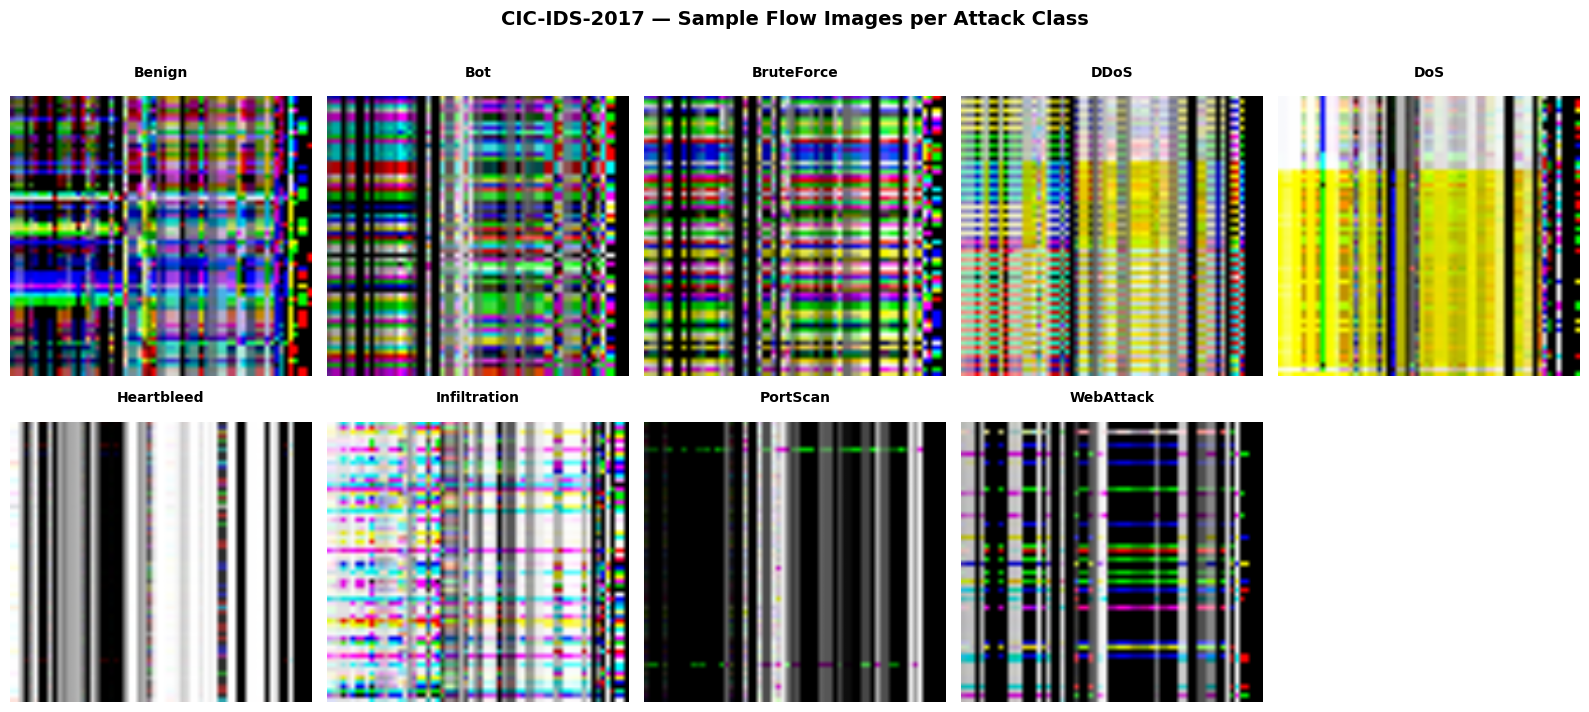

Saved → /kaggle/working/results/sample_images_.png


In [32]:
def visualise_class_samples(image_root: str, title: str = '', split: str = 'train'):
    """Show one sample image per class that exists in the dataset."""
    class_dirs = sorted([
        d for d in glob.glob(os.path.join(image_root, split, '*'))
        if os.path.isdir(d)
    ])
    if not class_dirs:
        print(f'No class folders found under {image_root}/{split}')
        return

    n_cols = 5
    n_rows = math.ceil(len(class_dirs) / n_cols)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 3.2, n_rows * 3.5))
    axes = np.array(axes).flatten()

    for ax in axes:
        ax.axis('off')

    for idx, cdir in enumerate(class_dirs):
        cname = os.path.basename(cdir)
        imgs  = glob.glob(os.path.join(cdir, '*.png'))
        if not imgs:
            continue
        # Pick a representative image from the middle of the list
        img_path = imgs[len(imgs) // 2]
        img = cv2.imread(img_path)
        if img is None:
            continue
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        ax = axes[idx]
        ax.imshow(img, aspect='auto')
        ax.set_title(cname.replace('_', '\n'), fontsize=10, fontweight='bold', pad=4)
        ax.axis('off')
        # Count available images
        n_imgs = len(imgs)
        ax.set_xlabel(f'{n_imgs:,} images', fontsize=8)
        ax.xaxis.set_label_position('top')

    suptitle = title or f'Sample Network-Flow Images — {os.path.basename(image_root)}'
    fig.suptitle(suptitle, fontsize=14, fontweight='bold', y=1.01)
    plt.tight_layout()
    save_path = os.path.join(RESULTS_DIR, f'sample_images_{os.path.basename(image_root)}.png')
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved → {save_path}')


visualise_class_samples(IMG_TRAIN_DIR, title='CIC-IDS-2017 — Sample Flow Images per Attack Class')

## 8 · Dataset & DataLoader

`torchvision.datasets.ImageFolder` reads PNGs directly.
A **WeightedRandomSampler** ensures every training batch has balanced class
representation — equivalent to oversampling minority attack classes.

In [21]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_transform = T.Compose([
    T.RandomHorizontalFlip(),
    T.RandomVerticalFlip(),
    T.ColorJitter(brightness=0.1, contrast=0.1),
    T.ToTensor(),
    T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

eval_transform = T.Compose([
    T.ToTensor(),
    T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])


def make_weighted_sampler(dataset: tv_datasets.ImageFolder) -> WeightedRandomSampler:
    """Square-root smoothed sampler — less aggressive than pure 1/count."""
    targets = np.array(dataset.targets)
    class_counts = np.bincount(targets, minlength=len(dataset.classes))
    class_weights = 1.0 / np.sqrt(np.maximum(class_counts, 1).astype(np.float64))
    sample_weights = class_weights[targets]
    return WeightedRandomSampler(
        weights=torch.DoubleTensor(sample_weights),
        num_samples=len(sample_weights),
        replacement=True
    )


def build_loaders(image_root: str, batch_size: int = BATCH_SIZE):
    """Build train / val / test DataLoaders from pre-generated PNG folders."""

    def get_valid_classes(root):
        valid = []
        for d in sorted(os.listdir(root)):
            full = os.path.join(root, d)
            if os.path.isdir(full) and len(glob.glob(os.path.join(full, '*.png'))) > 0:
                valid.append(d)
        return valid

    train_valid = set(get_valid_classes(os.path.join(image_root, 'train')))
    val_valid   = set(get_valid_classes(os.path.join(image_root, 'val')))
    test_valid  = set(get_valid_classes(os.path.join(image_root, 'test')))

    keep_classes = sorted(train_valid & val_valid & test_valid)
    print(f'Classes with images in all splits ({len(keep_classes)}): {keep_classes}')

    missing = set(CLASS_NAMES) - set(keep_classes)
    if missing:
        print(f' Missing classes: {missing}')

    # Delete folders not present in all splits
    for split in ('train', 'val', 'test'):
        for d in os.listdir(os.path.join(image_root, split)):
            if d not in keep_classes:
                folder = os.path.join(image_root, split, d)
                shutil.rmtree(folder, ignore_errors=True)

    train_ds = tv_datasets.ImageFolder(
        os.path.join(image_root, 'train'), transform=train_transform)
    val_ds   = tv_datasets.ImageFolder(
        os.path.join(image_root, 'val'),   transform=eval_transform)
    test_ds  = tv_datasets.ImageFolder(
        os.path.join(image_root, 'test'),  transform=eval_transform)

    sampler = make_weighted_sampler(train_ds)

    train_loader = DataLoader(
        train_ds, batch_size=batch_size, sampler=sampler,
        num_workers=NUM_WORKERS, pin_memory=(DEVICE=='cuda'))
    val_loader   = DataLoader(
        val_ds, batch_size=batch_size * 2, shuffle=False,
        num_workers=NUM_WORKERS, pin_memory=(DEVICE=='cuda'))
    test_loader  = DataLoader(
        test_ds, batch_size=batch_size * 2, shuffle=False,
        num_workers=NUM_WORKERS, pin_memory=(DEVICE=='cuda'))

    print(f'Train: {len(train_ds):,} images | Val: {len(val_ds):,} | Test: {len(test_ds):,}')
    print(f'Classes ({len(train_ds.classes)}): {train_ds.classes}')

    counts       = np.bincount(np.array(train_ds.targets), minlength=len(train_ds.classes))
    loss_weights = 1.0 / np.maximum(counts, 1).astype(np.float32)
    loss_weights = loss_weights / loss_weights.sum() * len(train_ds.classes)
    loss_weights = torch.tensor(loss_weights).to(DEVICE)

    return train_loader, val_loader, test_loader, train_ds.classes, loss_weights


train_loader, val_loader, test_loader_2017, class_names, loss_weights = build_loaders(IMG_TRAIN_DIR)
n_classes = len(class_names)
print(f'\nLoss weights (imbalance correction):')
for cname, w in zip(class_names, loss_weights.cpu().numpy()):
    print(f'  {cname:<22}: {w:.4f}')

Classes with images in all splits (9): ['Benign', 'Bot', 'BruteForce', 'DDoS', 'DoS', 'Heartbleed', 'Infiltration', 'PortScan', 'WebAttack']
Train: 12,009 images | Val: 2,570 | Test: 2,570
Classes (9): ['Benign', 'Bot', 'BruteForce', 'DDoS', 'DoS', 'Heartbleed', 'Infiltration', 'PortScan', 'WebAttack']

Loss weights (imbalance correction):
  Benign                : 0.0543
  Bot                   : 1.3187
  BruteForce            : 1.5077
  DDoS                  : 0.9685
  DoS                   : 0.4885
  Heartbleed            : 1.2886
  Infiltration          : 1.2923
  PortScan              : 0.7627
  WebAttack             : 1.3187


## 9 · Model Builders 

| Model | Params | 
|-------|--------|
| InceptionV3 | 23.9 M |
| MobileNetV3Small | 2.9 M |
| EfficientNetV2B0 | 7.2 M |

In [22]:
class IDSClassifier(nn.Module):
    def __init__(self, backbone: nn.Module, pool_out: int, n_classes: int, name: str,
                 aux_classifier=None):
        super().__init__()
        self.name           = name
        self.backbone       = backbone
        self.aux_classifier = aux_classifier   # InceptionV3 aux head
        self.head = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.BatchNorm1d(pool_out),
            nn.Linear(pool_out, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(DROPOUT_RATE),
            nn.Linear(512, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(DROPOUT_RATE / 2),
            nn.Linear(256, n_classes),
        )

    def forward(self, x):
        out = self.backbone(x)
        # InceptionV3 returns an InceptionOutputs namedtuple during training
        if isinstance(out, tuple):
            out = out[0]
        if out.dim() == 2:
            out = out.unsqueeze(-1).unsqueeze(-1)
        return self.head(out)


def freeze_backbone(model: IDSClassifier):
    for p in model.backbone.parameters():
        p.requires_grad = False

def unfreeze_top_n(model: IDSClassifier, n: int):
    all_params = list(model.backbone.parameters())
    for p in all_params[-n:]:
        p.requires_grad = True


def build_inceptionv3(nc: int) -> IDSClassifier:
    base = tv_models.inception_v3(weights=tv_models.Inception_V3_Weights.IMAGENET1K_V1)
    base.aux_logits = False
    base.AuxLogits  = None    # physically remove the aux branch
    base.fc         = nn.Identity()
    return IDSClassifier(base, 2048, nc, 'InceptionV3')

def build_mobilenet_v3_small(nc: int) -> IDSClassifier:
    base     = tv_models.mobilenet_v3_small(
                   weights=tv_models.MobileNet_V3_Small_Weights.IMAGENET1K_V1)
    backbone = base.features
    return IDSClassifier(backbone, 576, nc, 'MobileNetV3Small')

def build_efficientnet_v2_b0(nc: int) -> IDSClassifier:
    base     = tv_models.efficientnet_v2_s(
                   weights=tv_models.EfficientNet_V2_S_Weights.IMAGENET1K_V1)
    backbone = base.features
    return IDSClassifier(backbone, 1280, nc, 'EfficientNetV2B0')

MODEL_BUILDERS = {
    'InceptionV3'      : build_inceptionv3,
    'MobileNetV3Small' : build_mobilenet_v3_small,
    'EfficientNetV2B0' : build_efficientnet_v2_b0,
}

models = {}
for name in CNN_MODELS:
    m = MODEL_BUILDERS[name](n_classes).to(DEVICE)
    freeze_backbone(m)
    models[name] = m
    params = sum(p.numel() for p in m.parameters())
    train_params = sum(p.numel() for p in m.parameters() if p.requires_grad)
    print(f'{name:<22}: total={params/1e6:.1f}M  trainable(frozen)={train_params/1e3:.0f}K')
print('\nModels built ✓')

Downloading: "https://download.pytorch.org/models/inception_v3_google-0cc3c7bd.pth" to /root/.cache/torch/hub/checkpoints/inception_v3_google-0cc3c7bd.pth


100%|██████████| 104M/104M [00:00<00:00, 210MB/s] 


InceptionV3           : total=23.0M  trainable(frozen)=1187K
Downloading: "https://download.pytorch.org/models/mobilenet_v3_small-047dcff4.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_small-047dcff4.pth


100%|██████████| 9.83M/9.83M [00:00<00:00, 160MB/s]

MobileNetV3Small      : total=1.4M  trainable(frozen)=430K


Downloading: "https://download.pytorch.org/models/efficientnet_v2_s-dd5fe13b.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_v2_s-dd5fe13b.pth


100%|██████████| 82.7M/82.7M [00:00<00:00, 195MB/s]


EfficientNetV2B0      : total=21.0M  trainable(frozen)=792K

Models built ✓


## 10 · Training Utilities (Checkpoint + Train/Eval Loop)

In [35]:
def save_checkpoint(model, optimizer, scheduler, epoch, best_acc, phase, name):
    path = os.path.join(MODEL_SAVE_DIR, f'{name}_{phase}_checkpoint.pt')
    torch.save({
        'epoch': epoch, 'phase': phase, 'best_acc': best_acc,
        'model': model.state_dict(),
        'optimizer': optimizer.state_dict(),
        'scheduler': scheduler.state_dict(),
    }, path)

def load_checkpoint(model, optimizer, scheduler, name, phase):
    path = os.path.join(MODEL_SAVE_DIR, f'{name}_{phase}_checkpoint.pt')
    if not os.path.exists(path):
        return 1, 0.0
    ck = torch.load(path, map_location=DEVICE)
    model.load_state_dict(ck['model'])
    try:
        optimizer.load_state_dict(ck['optimizer'])
        scheduler.load_state_dict(ck['scheduler'])
    except ValueError:
        print(f'  Optimizer state mismatch — starting {phase} optimizer fresh')
    print(f'  Resumed {name}/{phase} from epoch {ck["epoch"]} (best acc={ck["best_acc"]:.4f})')
    return ck['epoch'] + 1, ck['best_acc']


def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    loss_sum, correct, n = 0.0, 0, 0
    pbar = tqdm(loader, desc='  train', leave=False)
    for imgs, lbls in pbar:
        imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)
        optimizer.zero_grad()
        out  = model(imgs)
        loss = criterion(out, lbls)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 5.0)
        optimizer.step()
        loss_sum += loss.item() * imgs.size(0)
        correct  += (out.argmax(1) == lbls).sum().item()
        n        += imgs.size(0)
        pbar.set_postfix(loss=f'{loss.item():.4f}', acc=f'{correct/n:.4f}')
    return loss_sum / n, correct / n


@torch.no_grad()
def eval_epoch(model, loader, criterion):
    model.eval()
    loss_sum, correct, n = 0.0, 0, 0
    for imgs, lbls in loader:
        imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)
        out  = model(imgs)
        loss = criterion(out, lbls)
        loss_sum += loss.item() * imgs.size(0)
        correct  += (out.argmax(1) == lbls).sum().item()
        n        += imgs.size(0)
    return loss_sum / n, correct / n


def train_phase(model, train_loader, val_loader, optimizer, scheduler,
                n_epochs, phase_name, model_name):
    criterion = nn.CrossEntropyLoss(weight=loss_weights)
    start_ep, best_acc = load_checkpoint(model, optimizer, scheduler, model_name, phase_name)
    best_weights = copy.deepcopy(model.state_dict())
    patience_ctr = 0
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

    for ep in range(start_ep, n_epochs + 1):
        tr_loss, tr_acc = train_one_epoch(model, train_loader, criterion, optimizer)
        va_loss, va_acc = eval_epoch(model, val_loader, criterion)
        scheduler.step(va_loss)

        history['train_loss'].append(tr_loss)
        history['val_loss'].append(va_loss)
        history['train_acc'].append(tr_acc)
        history['val_acc'].append(va_acc)

        improved = '✓' if va_acc > best_acc else ' '
        print(f'  [{phase_name}] Ep {ep:>2}/{n_epochs}  '
              f'tr_loss={tr_loss:.4f}  tr_acc={tr_acc:.4f}  '
              f'va_loss={va_loss:.4f}  va_acc={va_acc:.4f}  {improved}')

        if va_acc > best_acc:
            best_acc = va_acc
            best_weights = copy.deepcopy(model.state_dict())
            patience_ctr = 0
            save_checkpoint(model, optimizer, scheduler, ep, best_acc, phase_name, model_name)
        else:
            patience_ctr += 1
            if patience_ctr >= PATIENCE:
                print(f'  Early stop at epoch {ep}')
                break

    model.load_state_dict(best_weights)
    return history, best_acc


print('Training utilities defined ✓')

Training utilities defined ✓


## 11 · Train All Three Models

**Phase 1** — backbone frozen, only the classification head trains (`lr=1e-4`)  
**Phase 2** — top-N backbone layers unfrozen for fine-tuning (`lr=1e-5`)


In [ ]:
training_histories = {}

for model_name in CNN_MODELS:
    print(f'\n{"="*60}')
    print(f'  Training: {model_name}')
    print(f'{"="*60}')
    model = models[model_name]

    # Phase 1: Frozen backbone
    freeze_backbone(model)
    optimizer = optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=LR_FROZEN, weight_decay=WEIGHT_DECAY)
    scheduler = ReduceLROnPlateau(optimizer, patience=2, factor=0.5)
    print(f'  Phase 1 — backbone frozen')
    h1, best = train_phase(model, train_loader, val_loader, optimizer, scheduler,
                           EPOCHS_FROZEN, 'Phase1', model_name)

    # Phase 2: Fine-tune top layers
    n_unfreeze = UNFREEZE_TOP.get(model_name, 10)
    unfreeze_top_n(model, n_unfreeze)
    optimizer = optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=LR_FINE, weight_decay=WEIGHT_DECAY)
    scheduler = ReduceLROnPlateau(optimizer, patience=2, factor=0.5)
    print(f'  Phase 2 — top {n_unfreeze} backbone params unfrozen')
    h2, best = train_phase(model, train_loader, val_loader, optimizer, scheduler,
                           EPOCHS_FINE, 'Phase2', model_name)

    training_histories[model_name] = {'h1': h1, 'h2': h2, 'best_acc': best}

    # Save final model weights
    torch.save(model.state_dict(),
               os.path.join(MODEL_SAVE_DIR, f'{model_name}_best.pt'))
    print(f'  Saved best model → {model_name}_best.pt  (val_acc={best:.4f})')

print('\n All models trained!')


  Training: InceptionV3
  Phase 1 — backbone frozen


  train:   0%|          | 0/188 [00:00<?, ?it/s]

  [Phase1] Ep  1/5  tr_loss=1.0403  tr_acc=0.4538  va_loss=1.5786  va_acc=0.2895  ✓


  train:   0%|          | 0/188 [00:00<?, ?it/s]

  [Phase1] Ep  2/5  tr_loss=0.1908  tr_acc=0.6976  va_loss=1.0127  va_acc=0.6720  ✓


...

  [Phase2] Ep  8/10  tr_loss=0.0212  tr_acc=0.9649  va_loss=0.1763  va_acc=0.9506  ✓


  train:   0%|          | 0/188 [00:00<?, ?it/s]

  [Phase2] Ep  9/10  tr_loss=0.0222  tr_acc=0.9650  va_loss=0.1804  va_acc=0.9482   


  train:   0%|          | 0/188 [00:00<?, ?it/s]

  [Phase2] Ep 10/10  tr_loss=0.0215  tr_acc=0.9684  va_loss=0.1759  va_acc=0.9444   
  Saved best model → EfficientNetV2B0_best.pt  (val_acc=0.9506)

✅ All models trained!


## 12 · Learning Curves

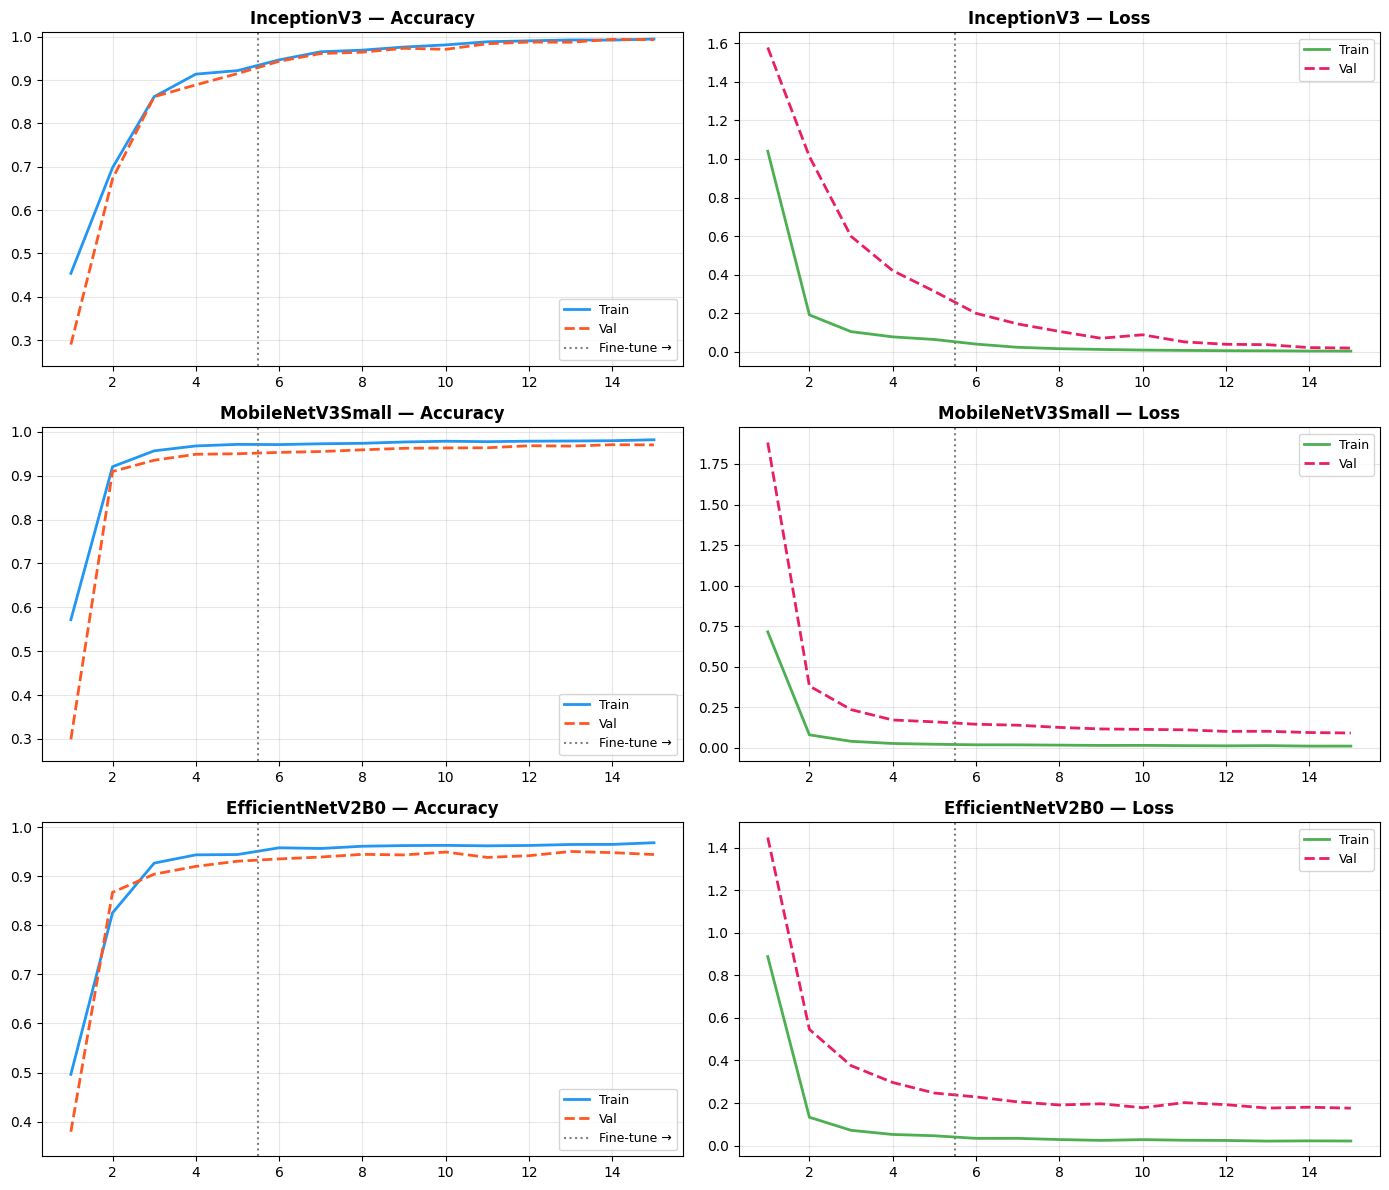

In [37]:
fig, axes = plt.subplots(len(CNN_MODELS), 2, figsize=(14, 4 * len(CNN_MODELS)))
if len(CNN_MODELS) == 1: axes = [axes]

for row, name in enumerate(CNN_MODELS):
    h1, h2 = training_histories[name]['h1'], training_histories[name]['h2']
    sep = len(h1['train_acc'])
    acc      = h1['train_acc'] + h2['train_acc']
    val_acc  = h1['val_acc']   + h2['val_acc']
    loss     = h1['train_loss']+ h2['train_loss']
    val_loss = h1['val_loss']  + h2['val_loss']
    eps = range(1, len(acc) + 1)

    ax_a, ax_l = axes[row]
    ax_a.plot(eps, acc,     label='Train', color='#2196F3', lw=2)
    ax_a.plot(eps, val_acc, label='Val',   color='#FF5722', lw=2, ls='--')
    ax_a.axvline(sep + 0.5, color='gray', ls=':', label='Fine-tune →')
    ax_a.set_title(f'{name} — Accuracy', fontweight='bold')
    ax_a.set_ylim(max(0, min(acc + val_acc) - 0.05), 1.01)
    ax_a.legend(fontsize=9); ax_a.grid(alpha=0.3)

    ax_l.plot(eps, loss,     label='Train', color='#4CAF50', lw=2)
    ax_l.plot(eps, val_loss, label='Val',   color='#E91E63', lw=2, ls='--')
    ax_l.axvline(sep + 0.5, color='gray', ls=':')
    ax_l.set_title(f'{name} — Loss', fontweight='bold')
    ax_l.legend(fontsize=9); ax_l.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'training_curves.png'), dpi=130, bbox_inches='tight')
plt.show()

## 13 · Load & Generate CIC-IDS-2018 Test Images


In [ ]:
import shutil


for f in os.listdir(MODEL_SAVE_DIR):
    size = os.path.getsize(os.path.join(MODEL_SAVE_DIR, f)) / 1e6
    print(f'  {f:<50} {size:.1f} MB')

  InceptionV3_Phase1_checkpoint.pt                   101.8 MB
  InceptionV3_Phase2_checkpoint.pt                   242.3 MB
  EfficientNetV2B0_Phase2_checkpoint.pt              101.9 MB
  MobileNetV3Small_Phase2_checkpoint.pt              11.3 MB
  EfficientNetV2B0_Phase1_checkpoint.pt              91.2 MB
  MobileNetV3Small_best.pt                           5.6 MB
  feature_processor.pkl                              0.5 MB
  InceptionV3_best.pt                                92.3 MB
  y_raw.npy                                          129.9 MB
  MobileNetV3Small_Phase1_checkpoint.pt              9.0 MB
  EfficientNetV2B0_best.pt                           84.8 MB
  X_raw.npy                                          4155.6 MB


In [51]:
import shutil, os

# Zip model weights
shutil.make_archive('/kaggle/working/models_backup', 'zip', MODEL_SAVE_DIR)
print(f'Models zip size: {os.path.getsize("/kaggle/working/models_backup.zip")/1e6:.1f} MB')

# Zip processor files only (small)
os.makedirs('/kaggle/working/processors', exist_ok=True)
import shutil as sh
for f in os.listdir(MODEL_SAVE_DIR):
    if f.endswith('.pkl'):
        sh.copy(os.path.join(MODEL_SAVE_DIR, f), '/kaggle/working/processors/')
shutil.make_archive('/kaggle/working/processors_backup', 'zip', '/kaggle/working/processors')
print(f'Processors zip size: {os.path.getsize("/kaggle/working/processors_backup.zip")/1e6:.1f} MB')

# List what's been zipped
print('\nModels saved:')
for f in os.listdir(MODEL_SAVE_DIR):
    size = os.path.getsize(os.path.join(MODEL_SAVE_DIR, f))/1e6
    print(f'  {f:<50} {size:.1f} MB')

Models zip size: 1681.1 MB
Processors zip size: 0.1 MB

Models saved:
  InceptionV3_Phase1_checkpoint.pt                   101.8 MB
  InceptionV3_Phase2_checkpoint.pt                   242.3 MB
  EfficientNetV2B0_Phase2_checkpoint.pt              101.9 MB
  MobileNetV3Small_Phase2_checkpoint.pt              11.3 MB
  EfficientNetV2B0_Phase1_checkpoint.pt              91.2 MB
  MobileNetV3Small_best.pt                           5.6 MB
  feature_processor.pkl                              0.5 MB
  InceptionV3_best.pt                                92.3 MB
  y_raw.npy                                          129.9 MB
  MobileNetV3Small_Phase1_checkpoint.pt              9.0 MB
  EfficientNetV2B0_best.pt                           84.8 MB
  X_raw.npy                                          4155.6 MB


In [ ]:

print('Fitting dedicated 2018 processor …')

processor_2018 = FeatureProcessor(n_features=N_FEATURES)
sample_dfs, sample_rows = [], 0
fit_sample_rows = 300_000

files_2018 = sorted(glob.glob(os.path.join(TEST_DATA_DIR, '**', '*.csv'), recursive=True))
for fp in files_2018:
    if sample_rows >= fit_sample_rows:
        break
    for chunk in pd.read_csv(fp, chunksize=CHUNK_SIZE, low_memory=False,
                              encoding='latin-1', on_bad_lines='skip'):
        lbl_col = next((c for c in chunk.columns
                        if c.strip().lower() == 'label'), None)
        if lbl_col is None:
            continue
        chunk[lbl_col] = chunk[lbl_col].astype(str).str.strip()
        chunk['_lbl']  = chunk[lbl_col].map(LABEL_MAP)
        chunk = chunk.dropna(subset=['_lbl'])
        if len(chunk) == 0:
            continue
        drop    = [lbl_col, '_lbl'] + [c for c in DROP_COLUMNS if c in chunk.columns]
        feat_df = chunk.drop(columns=drop, errors='ignore')
        n_take  = min(len(feat_df), fit_sample_rows - sample_rows)
        sample_dfs.append(feat_df.sample(n=n_take, random_state=RANDOM_SEED)
                          if n_take < len(feat_df) else feat_df)
        sample_rows += n_take
        if sample_rows >= fit_sample_rows:
            break

sample_df = pd.concat(sample_dfs, ignore_index=True)
del sample_dfs; gc.collect()
processor_2018.fit_transform(sample_df)
del sample_df; gc.collect()

# Save 
proc_2018_path = os.path.join(MODEL_SAVE_DIR, 'feature_processor_2018.pkl')
with open(proc_2018_path, 'wb') as fh:
    pickle.dump(processor_2018, fh)
print(f'processor_2018 saved → {proc_2018_path}')


test_files = sorted(glob.glob(os.path.join(TEST_DATA_DIR, '**', '*.csv'), recursive=True))[:1]
chunk = next(pd.read_csv(test_files[0], chunksize=1000, low_memory=False,
                          encoding='latin-1', on_bad_lines='skip'))
lbl_col = next(c for c in chunk.columns if c.strip().lower() == 'label')
drop = [lbl_col] + [c for c in DROP_COLUMNS if c in chunk.columns]
feat_df = chunk.drop(columns=drop, errors='ignore')
X_check = processor_2018.transform(feat_df)
print(f'Verification — mean={X_check.mean():.4f}  min={X_check.min():.4f}  max={X_check.max():.4f}')

Fitting dedicated 2018 processor …
processor_2018 saved → /kaggle/working/saved_models/feature_processor_2018.pkl
Verification — mean=0.1490  min=0.0000  max=1.0000


In [7]:
print('Loading CIC-IDS-2018 (test set) …')
X_2018, y_2018, _ = load_raw_features(
    TEST_DATA_DIR, processor=processor_2018, fit=False)



Loading CIC-IDS-2018 (test set) …
Found 10 CSV file(s)

Pass 2a: counting valid rows … 16,232,943
Pass 2b: transforming → disk (4.16 GB)


  02-14-2018.csv: 0it [00:00, ?it/s]

  02-15-2018.csv: 0it [00:00, ?it/s]

  02-16-2018.csv: 0it [00:00, ?it/s]

  02-20-2018.csv: 0it [00:00, ?it/s]

...

  02-23-2018.csv: 0it [00:00, ?it/s]

  02-28-2018.csv: 0it [00:00, ?it/s]

  03-01-2018.csv: 0it [00:00, ?it/s]

  03-02-2018.csv: 0it [00:00, ?it/s]


Feature matrix: (16232943, 64)  dtype=float32
Class distribution:
  Benign                 : 13,484,708
  Bot                    :  286,191
  BruteForce             :  381,790
  DDoS                   : 1,263,933
  DoS                    :  654,300
  Infiltration           :  161,934
  WebAttack              :       87



⏳ Generating 2018 test images …
Generating 84,546 images from 16,232,943 rows …
  (each image = 192 consecutive rows × 64 features)


Generating images:   0%|          | 0/84546 [00:00<?, ?it/s]


Splitting images per class (stratified) …

📊 Images per class:
  Benign                : 70,403
  Bot                   :  1,529
  BruteForce            :  1,999
  DDoS                  :  6,687
  DoS                   :  3,249
  Infiltration          :    679

Total: 84,546 images
  Train: 0  Val: 6  Test: 84,540


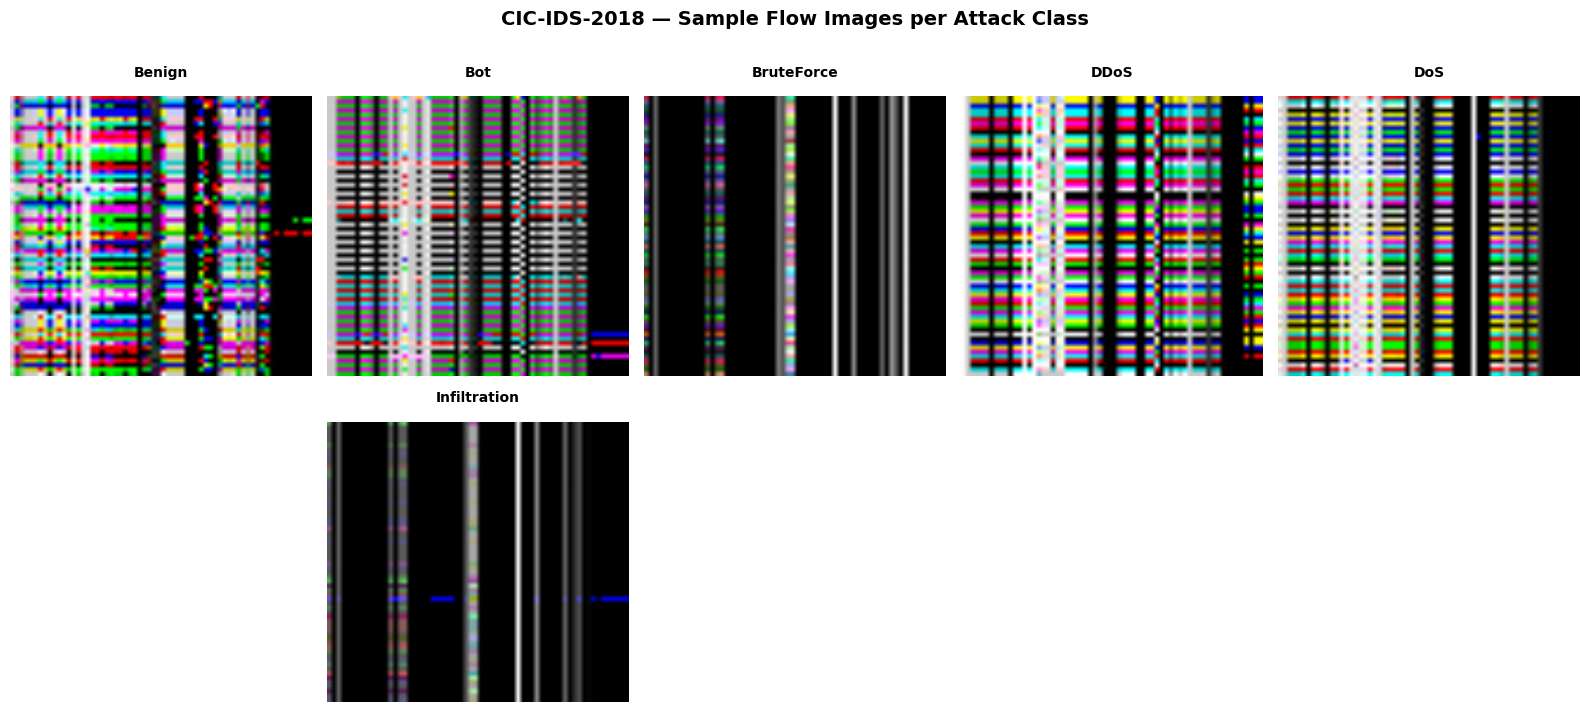

Saved → /kaggle/working/results/sample_images_.png
RAM freed ✓


In [17]:
print('\n⏳ Generating 2018 test images …')
manifest_2018 = generate_and_save_images(
    X_2018, y_2018, IMG_TEST_DIR, 
    split_ratios=(0.0, 0.0, 1.0))  

visualise_class_samples(IMG_TEST_DIR,
    title='CIC-IDS-2018 — Sample Flow Images per Attack Class',
    split='test')

del X_2018, y_2018; gc.collect()
print('RAM freed ✓')

In [26]:
import shutil

# Check disk usage
import subprocess
result = subprocess.run(['df', '-h', '/kaggle/working'], capture_output=True, text=True)
print(result.stdout)

# Check what's taking space
for d in os.listdir('/kaggle/working'):
    full = os.path.join('/kaggle/working', d)
    if os.path.isdir(full):
        size = subprocess.run(['du', '-sh', full], capture_output=True, text=True)
        print(size.stdout.strip())
    else:
        size = os.path.getsize(full) / 1e9
        print(f'{size:.2f} GB  {d}')

Filesystem      Size  Used Avail Use% Mounted on
/dev/loop1       20G   14G  6.5G  67% /kaggle/working

0.21 GB  state.db
516K	/kaggle/working/processors
1.2M	/kaggle/working/results
1.4G	/kaggle/working/saved_models
12G	/kaggle/working/images_2018
60K	/kaggle/working/.virtual_documents


## 14 · Inference & Ensemble (Model Averaging)



In [32]:
# Verify class alignment before inference
print(f'Model output classes : {n_classes}')
print(f'2017 test classes    : {len(test_loader_2017.dataset.classes)}')
print(f'2017 class names     : {test_loader_2017.dataset.classes}')
print(f'Training class names : {class_names}')

# Check they match
if list(test_loader_2017.dataset.classes) != list(class_names):
    print(' CLASS MISMATCH — results will be wrong!')
else:
    print(' Classes match — safe to run inference')

Model output classes : 9
2017 test classes    : 9
2017 class names     : ['Benign', 'Bot', 'BruteForce', 'DDoS', 'DoS', 'Heartbleed', 'Infiltration', 'PortScan', 'WebAttack']
Training class names : ['Benign', 'Bot', 'BruteForce', 'DDoS', 'DoS', 'Heartbleed', 'Infiltration', 'PortScan', 'WebAttack']
 Classes match — safe to run inference


In [ ]:
@torch.no_grad()
def get_probabilities(model: IDSClassifier, loader: DataLoader) -> np.ndarray:
    """Return (N, n_classes) softmax probability array for a DataLoader."""
    model.eval()
    probs_list = []
    for imgs, _ in tqdm(loader, desc=f'  infer [{model.name}]', leave=False):
        logits = model(imgs.to(DEVICE))
        probs_list.append(torch.softmax(logits.cpu(), dim=1).numpy())
    return np.concatenate(probs_list, axis=0)


def predict_all(loader, y_true=None, label=''):
    """Run all 3 models + ensemble, print metrics."""
    proba_dict = {name: get_probabilities(m, loader) for name, m in models.items()}
    results = {'per_model': {}}

    print(f'\n── {label} ──────────────────────────────────────────')
    for name, proba in proba_dict.items():
        preds = proba.argmax(axis=1)
        results['per_model'][name] = {'preds': preds, 'proba': proba}
        if y_true is not None:
            acc = accuracy_score(y_true, preds)
            mcc = matthews_corrcoef(y_true, preds)
            print(f'  {name:<22}  acc={acc:.4f}  MCC={mcc:.4f}')

    # Soft voting 
    avg_proba  = np.stack(list(proba_dict.values()), axis=0).mean(axis=0)
    soft_preds = avg_proba.argmax(axis=1)
    results['soft'] = {'preds': soft_preds, 'proba': avg_proba}
    if y_true is not None:
        acc = accuracy_score(y_true, soft_preds)
        mcc = matthews_corrcoef(y_true, soft_preds)
        f1  = f1_score(y_true, soft_preds, average='weighted', zero_division=0)
        print(f'  {"ELETL-IDS (soft vote)":<22}  acc={acc:.4f}  MCC={mcc:.4f}  wF1={f1:.4f}  ← MODEL')

    return results


print('Inference helpers defined ✓')

#  Evaluate on 2017 test split 
print('\nEvaluating on CIC-IDS-2017 test split …')
y_test_2017 = np.array(test_loader_2017.dataset.targets)
results_2017 = predict_all(test_loader_2017, y_test_2017, label='CIC-IDS-2017 Test')

Inference helpers defined ✓

Evaluating on CIC-IDS-2017 test split …


  infer [InceptionV3]:   0%|          | 0/21 [00:00<?, ?it/s]

  infer [MobileNetV3Small]:   0%|          | 0/21 [00:00<?, ?it/s]

  infer [EfficientNetV2B0]:   0%|          | 0/21 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7d27a0bc4540>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1654, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1637, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7d27a0bc4540>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1654, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16


── CIC-IDS-2017 Test ──────────────────────────────────────────
  InceptionV3             acc=0.9856  MCC=0.9719
  MobileNetV3Small        acc=0.9615  MCC=0.9294
  EfficientNetV2B0        acc=0.9381  MCC=0.8904
  ELETL-IDS (soft vote)   acc=0.9813  MCC=0.9640  wF1=0.9817  ← MODEL


## 15 · Evaluate on CIC-IDS-2018 (Cross-Dataset Test)

In [38]:
# Remap 2018 class indices to match training class indices
train_class_to_idx = {name: idx for idx, name in enumerate(class_names)}
test_class_names   = test_ds_2018.classes

# Build remapping array: test_idx → train_idx
remap = np.array([
    train_class_to_idx.get(name, -1) 
    for name in test_class_names
])
print('Index remapping:')
for test_idx, (name, train_idx) in enumerate(zip(test_class_names, remap)):
    print(f'  2018 idx {test_idx} ({name}) → training idx {train_idx}')

# Apply remap to y_2018
y_2018_remapped = remap[y_2018]

# Check for any -1 (unmapped classes)
if (y_2018_remapped == -1).any():
    print(' Some classes could not be mapped — removing them')
    mask = y_2018_remapped != -1
    y_2018_remapped = y_2018_remapped[mask]

results_2018 = predict_all(
    test_loader_2018, y_2018_remapped, 
    label='CIC-IDS-2018 Cross-Dataset Test (remapped)')

Index remapping:
  2018 idx 0 (Benign) → training idx 0
  2018 idx 1 (Bot) → training idx 1
  2018 idx 2 (BruteForce) → training idx 2
  2018 idx 3 (DDoS) → training idx 3
  2018 idx 4 (DoS) → training idx 4
  2018 idx 5 (Infiltration) → training idx 6


  infer [InceptionV3]:   0%|          | 0/661 [00:00<?, ?it/s]

  infer [MobileNetV3Small]:   0%|          | 0/661 [00:00<?, ?it/s]

  infer [EfficientNetV2B0]:   0%|          | 0/661 [00:00<?, ?it/s]


── CIC-IDS-2018 Cross-Dataset Test (remapped) ──────────────────────────────────────────
  InceptionV3             acc=0.6457  MCC=0.2804
  MobileNetV3Small        acc=0.6904  MCC=0.2577
  EfficientNetV2B0        acc=0.3033  MCC=0.0741
  ELETL-IDS (soft vote)   acc=0.6692  MCC=0.2758  wF1=0.7323  ← MODEL


## 16 · Detailed Classification Report & MCC

In [40]:
def full_report(y_true, results, dataset_name):
    all_metrics = {}
    entries = (
        [(name, info['preds'], info['proba'])
         for name, info in results['per_model'].items()]
      + [('ELETL-IDS (soft vote)', results['soft']['preds'], results['soft']['proba'])]
    )
    present_labels = sorted(np.unique(y_true))
    present_names  = [CLASS_NAMES[i] if i < len(CLASS_NAMES) else str(i) for i in present_labels]

    for name, preds, proba in entries:
        acc  = accuracy_score(y_true, preds)
        mcc  = matthews_corrcoef(y_true, preds)
        wf1  = f1_score(y_true, preds, average='weighted', zero_division=0)
        mf1  = f1_score(y_true, preds, average='macro',    zero_division=0)
        all_metrics[name] = {'accuracy': acc, 'MCC': mcc, 'macro_F1': mf1, 'weighted_F1': wf1}

        print(f'\n{"─"*55}  {name}')
        print(classification_report(
            y_true, preds,
            labels=present_labels, target_names=present_names,
            zero_division=0))
        print(f'  MCC = {mcc:.4f}')

    # Summary table
    df = pd.DataFrame(all_metrics).T.round(4)
    print(f'\n=== {dataset_name} Summary ===')
    print(df.to_string())

    with open(os.path.join(RESULTS_DIR, f'metrics_{dataset_name}.json'), 'w') as fh:
        json.dump(all_metrics, fh, indent=2)

    return all_metrics

print('\n CIC-IDS-2017 detailed report:')
metrics_2017 = full_report(y_test_2017, results_2017, '2017')

print('\n CIC-IDS-2018 detailed report:')
metrics_2018 = full_report(y_2018, results_2018, '2018')


 CIC-IDS-2017 detailed report:

───────────────────────────────────────────────────────  InceptionV3
              precision    recall  f1-score   support

      Benign       1.00      0.98      0.99      1786
         Bot       0.99      1.00      0.99        73
  BruteForce       1.00      1.00      1.00        64
        DDoS       0.98      1.00      0.99       100
         DoS       0.91      0.96      0.93       198
Infiltration       0.99      1.00      0.99        74
    PortScan       1.00      1.00      1.00        75
   WebAttack       0.95      0.99      0.97       127
  Heartbleed       1.00      1.00      1.00        73

    accuracy                           0.99      2570
   macro avg       0.98      0.99      0.99      2570
weighted avg       0.99      0.99      0.99      2570

  MCC = 0.9719

───────────────────────────────────────────────────────  MobileNetV3Small
              precision    recall  f1-score   support

      Benign       1.00      0.95      0.97     

## 17 · Confusion Matrix

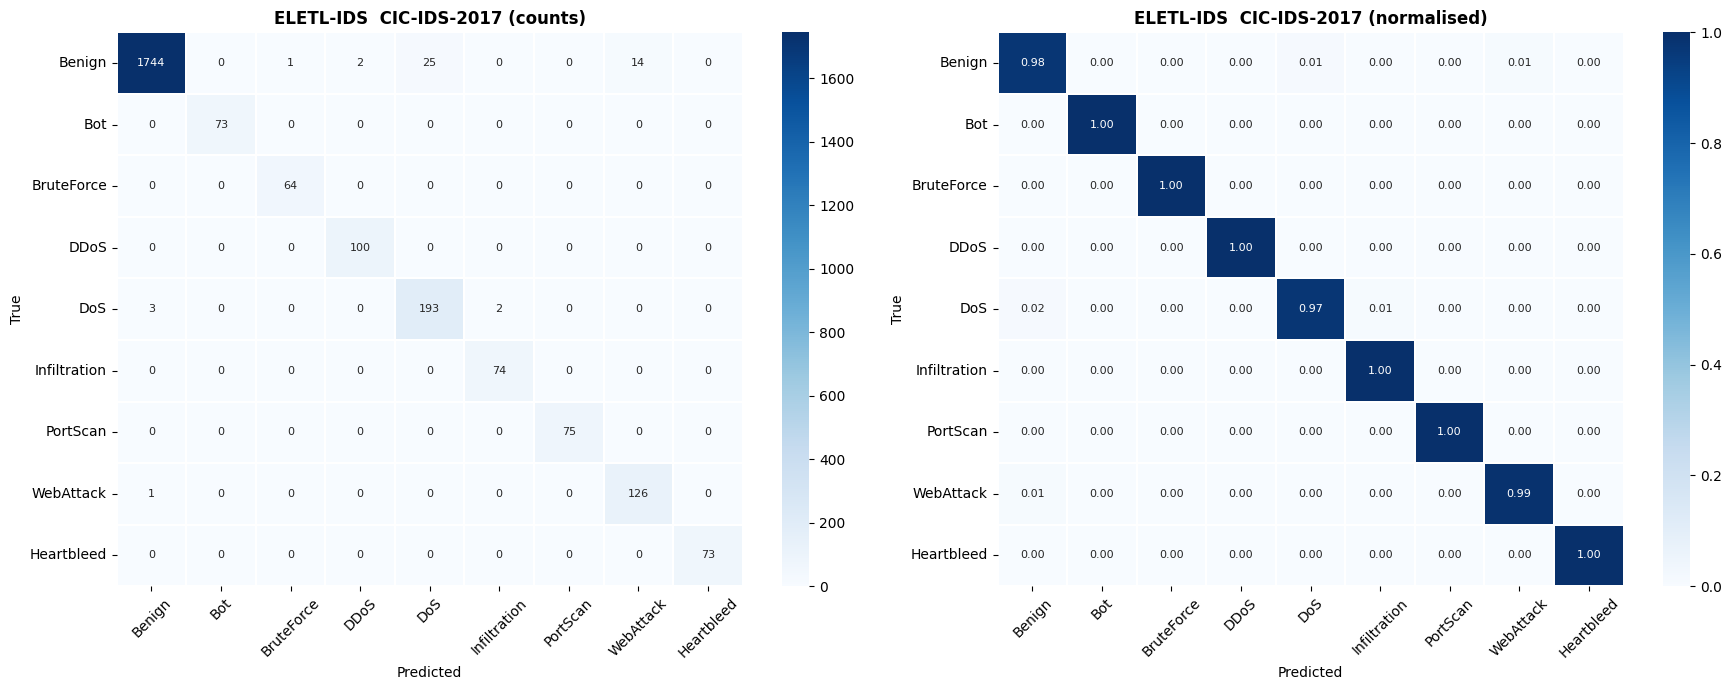

Saved → /kaggle/working/results/cm_2017.png


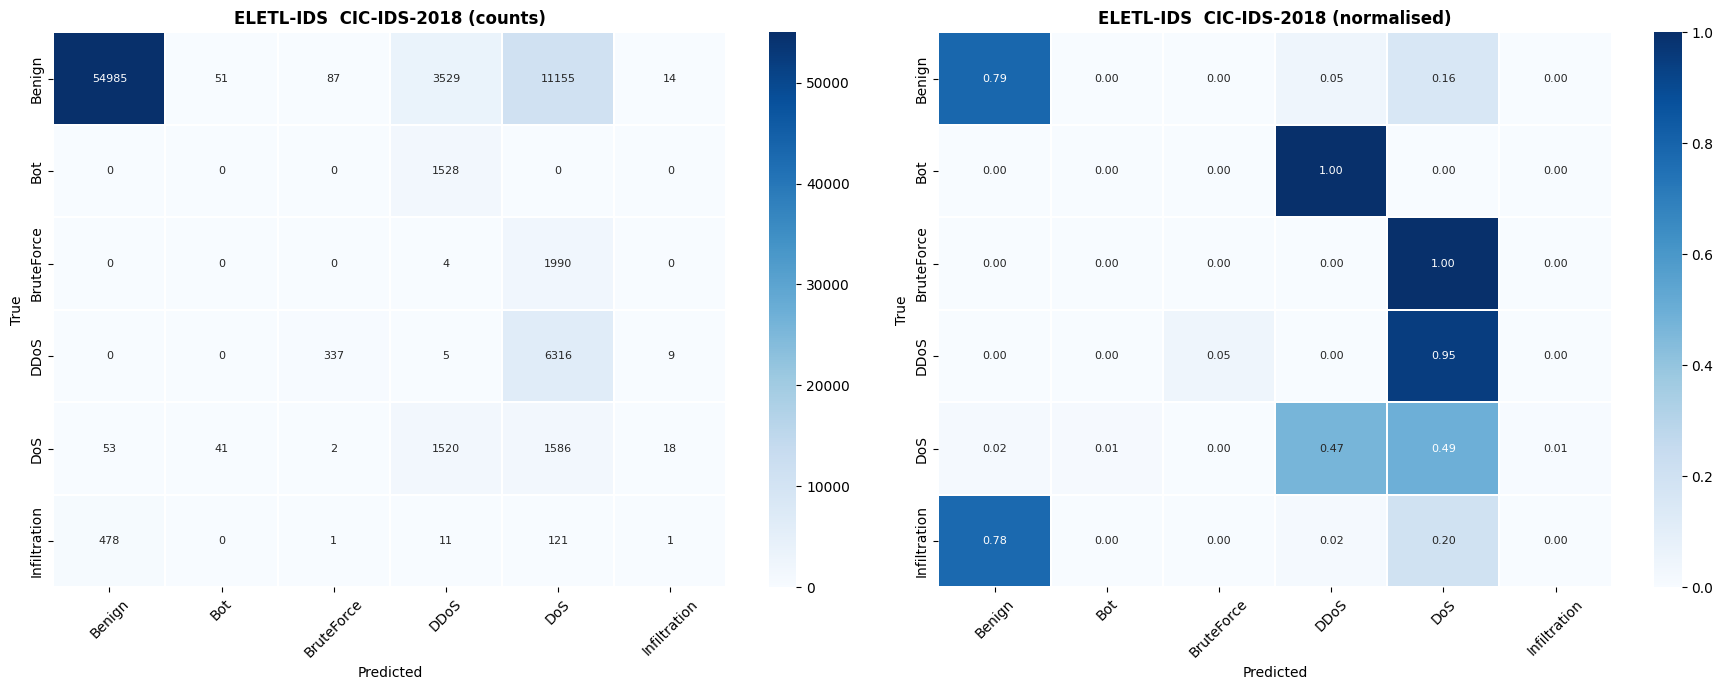

Saved → /kaggle/working/results/cm_2018.png


In [41]:
def plot_cm(y_true, y_pred, title, fname):
    present = sorted(np.unique(y_true))
    names   = [CLASS_NAMES[i] if i < len(CLASS_NAMES) else str(i) for i in present]
    cm      = confusion_matrix(y_true, y_pred, labels=present)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True).clip(1)

    fig, axes = plt.subplots(1, 2, figsize=(18, 7))
    for ax, data, fmt, sfx in zip(axes, [cm, cm_norm], ['d', '.2f'],
                                  ['(counts)', '(normalised)']):
        sns.heatmap(data, ax=ax, xticklabels=names, yticklabels=names,
                    cmap='Blues', fmt=fmt, annot=True, linewidths=0.3, annot_kws={'size': 8})
        ax.set_title(f'{title} {sfx}', fontweight='bold')
        ax.set_xlabel('Predicted'); ax.set_ylabel('True')
        ax.tick_params(axis='x', rotation=45)
    plt.tight_layout()
    path = os.path.join(RESULTS_DIR, fname)
    plt.savefig(path, dpi=130, bbox_inches='tight')
    plt.show()
    print(f'Saved → {path}')

plot_cm(y_test_2017, results_2017['soft']['preds'], 'ELETL-IDS  CIC-IDS-2017', 'cm_2017.png')
plot_cm(y_2018,      results_2018['soft']['preds'], 'ELETL-IDS  CIC-IDS-2018', 'cm_2018.png')

## 18 · ROC-AUC Curves

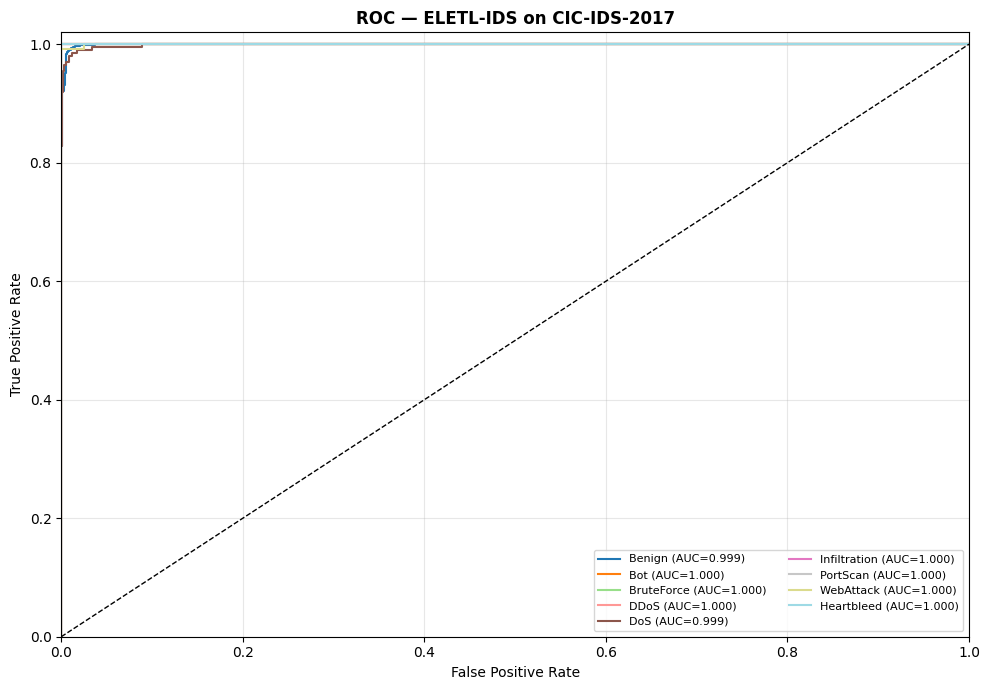

Saved → /kaggle/working/results/roc_2017.png


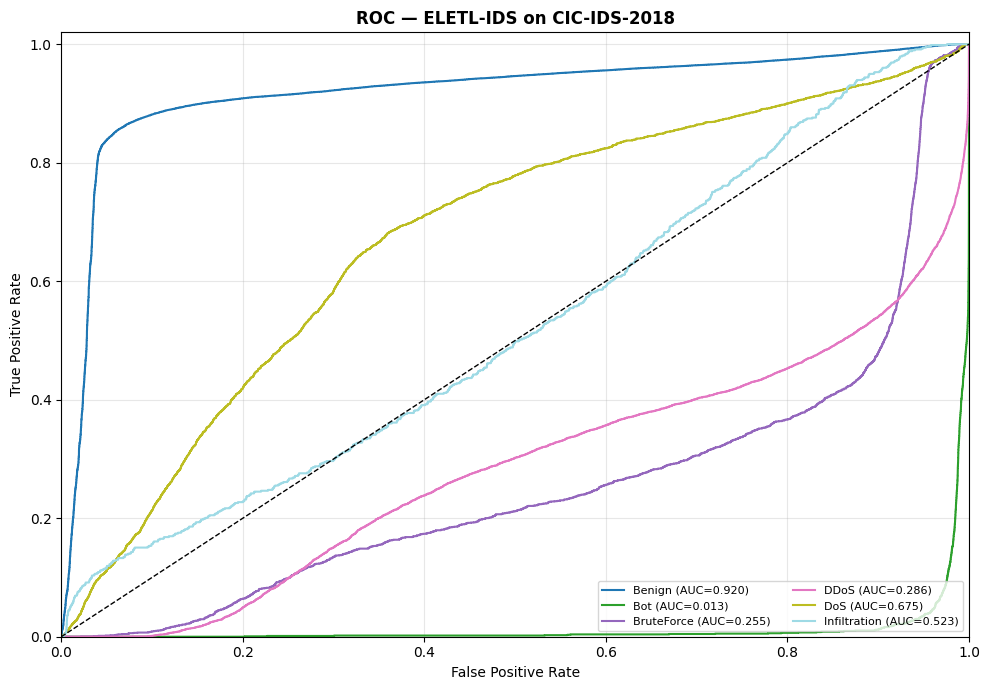

Saved → /kaggle/working/results/roc_2018.png


In [42]:
def plot_roc(y_true, proba, title, fname):
    n_cls = proba.shape[1]
    present = sorted(np.unique(y_true))
    y_bin = label_binarize(y_true, classes=list(range(n_cls)))
    colors = plt.cm.tab20(np.linspace(0, 1, len(present)))
    fig, ax = plt.subplots(figsize=(10, 7))
    for i, col in zip(present, colors):
        if y_bin[:, i].sum() == 0: continue
        fpr, tpr, _ = roc_curve(y_bin[:, i], proba[:, i])
        name = CLASS_NAMES[i] if i < len(CLASS_NAMES) else str(i)
        ax.plot(fpr, tpr, color=col, lw=1.5, label=f'{name} (AUC={auc(fpr,tpr):.3f})')
    ax.plot([0,1],[0,1],'k--', lw=1)
    ax.set_xlim([0,1]); ax.set_ylim([0,1.02])
    ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
    ax.set_title(title, fontweight='bold')
    ax.legend(loc='lower right', fontsize=8, ncol=2)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    path = os.path.join(RESULTS_DIR, fname)
    plt.savefig(path, dpi=130, bbox_inches='tight'); plt.show()
    print(f'Saved → {path}')

plot_roc(y_test_2017, results_2017['soft']['proba'], 'ROC — ELETL-IDS on CIC-IDS-2017', 'roc_2017.png')
plot_roc(y_2018,      results_2018['soft']['proba'], 'ROC — ELETL-IDS on CIC-IDS-2018', 'roc_2018.png')

## 19 · Final Summary Table

In [44]:
rows = []
for ds_name, metrics in [('CIC-IDS-2017', metrics_2017), ('CIC-IDS-2018', metrics_2018)]:
    for model_name, m in metrics.items():
        rows.append({
            'Dataset': ds_name,
            'Model': model_name,
            'Accuracy':    f"{m['accuracy']:.4f}",
            'MCC':         f"{m['MCC']:.4f}",
            'Macro F1':    f"{m['macro_F1']:.4f}",
            'Weighted F1': f"{m['weighted_F1']:.4f}",
        })

summary_df = pd.DataFrame(rows)
display(summary_df.style
    .set_caption('ELETL-IDS Results (Paper Replication)')
    .background_gradient(cmap='YlGn', subset=['Accuracy','MCC','Weighted F1'])
    .set_properties(**{'text-align': 'center'}))

summary_df.to_csv(os.path.join(RESULTS_DIR, 'final_summary.csv'), index=False)
print('\n Pipeline complete!')
print(f'All outputs saved to: {RESULTS_DIR}')

,Dataset,Model,Accuracy,MCC,Macro F1,Weighted F1
0,CIC-IDS-2017,InceptionV3,0.9856,0.9719,0.9855,0.9858
1,CIC-IDS-2017,MobileNetV3Small,0.9615,0.9294,0.9642,0.9631
2,CIC-IDS-2017,EfficientNetV2B0,0.9381,0.8904,0.9307,0.9414
3,CIC-IDS-2017,ELETL-IDS (soft vote),0.9813,0.9640,0.9809,0.9817
4,CIC-IDS-2018,InceptionV3,0.6457,0.2804,0.1122,0.7125
5,CIC-IDS-2018,MobileNetV3Small,0.6904,0.2583,0.1154,0.7488
6,CIC-IDS-2018,EfficientNetV2B0,0.3038,0.0749,0.0710,0.4320
7,CIC-IDS-2018,ELETL-IDS (soft vote),0.6692,0.2758,0.1119,0.7324



 Pipeline complete!
All outputs saved to: /kaggle/working/results/


# Converting into Binary Classifier to test 

In [23]:
# Load processors
with open(os.path.join(MODEL_SAVE_DIR, 'feature_processor.pkl'), 'rb') as fh:
    processor = pickle.load(fh)
processor_2018 = None
print('Processors loaded ✓')

# Load models
models = {}
for name in CNN_MODELS:
    m = MODEL_BUILDERS[name](n_classes).to(DEVICE)
    m.load_state_dict(torch.load(
        os.path.join(MODEL_SAVE_DIR, f'{name}_best.pt'),
        map_location=DEVICE))
    m.eval()
    models[name] = m
    print(f'  {name} loaded ✓')

# Build 2017 test loader
for d in os.listdir(os.path.join(IMG_TRAIN_DIR, 'test')):
    full = os.path.join(IMG_TRAIN_DIR, 'test', d)
    if os.path.isdir(full) and len(glob.glob(os.path.join(full, '*.png'))) == 0:
        shutil.rmtree(full)
test_ds_2017 = tv_datasets.ImageFolder(
    os.path.join(IMG_TRAIN_DIR, 'test'), transform=eval_transform)
test_loader_2017 = DataLoader(
    test_ds_2017, batch_size=BATCH_SIZE * 2,
    shuffle=False, num_workers=0, pin_memory=False)
y_test_2017 = np.array(test_ds_2017.targets)
print(f'2017: {len(test_ds_2017):,} images | classes: {test_ds_2017.classes}')

# Build 2018 test loader
for d in os.listdir(os.path.join(IMG_TEST_DIR, 'test')):
    full = os.path.join(IMG_TEST_DIR, 'test', d)
    if os.path.isdir(full) and len(glob.glob(os.path.join(full, '*.png'))) == 0:
        shutil.rmtree(full)
test_ds_2018 = tv_datasets.ImageFolder(
    os.path.join(IMG_TEST_DIR, 'test'), transform=eval_transform)
test_loader_2018 = DataLoader(
    test_ds_2018, batch_size=BATCH_SIZE * 2,
    shuffle=False, num_workers=0, pin_memory=False)
y_2018 = np.array(test_ds_2018.targets)
print(f'2018: {len(test_ds_2018):,} images | classes: {test_ds_2018.classes}')

# Set class names
class_names = test_ds_2017.classes
n_classes   = len(class_names)
print(f'\nTraining classes ({n_classes}): {class_names}')

# Remap 2018 labels to training indices
train_class_to_idx = {name: idx for idx, name in enumerate(class_names)}
remap = np.array([train_class_to_idx.get(name, -1)
                  for name in test_ds_2018.classes])
y_2018_remapped = remap[y_2018]
print(f'2018 remap: {list(zip(test_ds_2018.classes, remap))}')

Processors loaded ✓
  InceptionV3 loaded ✓
  MobileNetV3Small loaded ✓
  EfficientNetV2B0 loaded ✓
2017: 2,570 images | classes: ['Benign', 'Bot', 'BruteForce', 'DDoS', 'DoS', 'Heartbleed', 'Infiltration', 'PortScan', 'WebAttack']
2018: 84,540 images | classes: ['Benign', 'Bot', 'BruteForce', 'DDoS', 'DoS', 'Infiltration']

Training classes (9): ['Benign', 'Bot', 'BruteForce', 'DDoS', 'DoS', 'Heartbleed', 'Infiltration', 'PortScan', 'WebAttack']
2018 remap: [('Benign', np.int64(0)), ('Bot', np.int64(1)), ('BruteForce', np.int64(2)), ('DDoS', np.int64(3)), ('DoS', np.int64(4)), ('Infiltration', np.int64(6))]


In [24]:
# Define inference helpers (rerun these if not defined)
@torch.no_grad()
def get_probabilities(model, loader):
    model.eval()
    probs_list = []
    for imgs, _ in tqdm(loader, desc=f'  infer [{model.name}]', leave=False):
        logits = model(imgs.to(DEVICE))
        probs_list.append(torch.softmax(logits.cpu(), dim=1).numpy())
    return np.concatenate(probs_list, axis=0)

def predict_all(loader, y_true=None, label=''):
    proba_dict = {name: get_probabilities(m, loader) for name, m in models.items()}
    results = {'per_model': {}}
    print(f'\n── {label} ──────────────────────────────────────────')
    for name, proba in proba_dict.items():
        preds = proba.argmax(axis=1)
        results['per_model'][name] = {'preds': preds, 'proba': proba}
        if y_true is not None:
            acc = accuracy_score(y_true, preds)
            mcc = matthews_corrcoef(y_true, preds)
            print(f'  {name:<22}  acc={acc:.4f}  MCC={mcc:.4f}')
    avg_proba  = np.stack(list(proba_dict.values()), axis=0).mean(axis=0)
    soft_preds = avg_proba.argmax(axis=1)
    results['soft'] = {'preds': soft_preds, 'proba': avg_proba}
    if y_true is not None:
        acc = accuracy_score(y_true, soft_preds)
        mcc = matthews_corrcoef(y_true, soft_preds)
        f1  = f1_score(y_true, soft_preds, average='weighted', zero_division=0)
        print(f'  {"ELETL-IDS (soft vote)":<22}  acc={acc:.4f}  MCC={mcc:.4f}  wF1={f1:.4f}  ←  MODEL')
    return results

# Run inference
results_2017 = predict_all(test_loader_2017, y_test_2017, label='CIC-IDS-2017 Test')
results_2018 = predict_all(test_loader_2018, y_2018_remapped, label='CIC-IDS-2018 Cross-Dataset Test')

  infer [InceptionV3]:   0%|          | 0/21 [00:00<?, ?it/s]

  infer [MobileNetV3Small]:   0%|          | 0/21 [00:00<?, ?it/s]

  infer [EfficientNetV2B0]:   0%|          | 0/21 [00:00<?, ?it/s]


── CIC-IDS-2017 Test ──────────────────────────────────────────
  InceptionV3             acc=0.9856  MCC=0.9719
  MobileNetV3Small        acc=0.9615  MCC=0.9294
  EfficientNetV2B0        acc=0.9381  MCC=0.8904
  ELETL-IDS (soft vote)   acc=0.9813  MCC=0.9640  wF1=0.9817  ← PAPER MODEL


  infer [InceptionV3]:   0%|          | 0/661 [00:00<?, ?it/s]

  infer [MobileNetV3Small]:   0%|          | 0/661 [00:00<?, ?it/s]

  infer [EfficientNetV2B0]:   0%|          | 0/661 [00:00<?, ?it/s]


── CIC-IDS-2018 Cross-Dataset Test ──────────────────────────────────────────
  InceptionV3             acc=0.6457  MCC=0.2804
  MobileNetV3Small        acc=0.6904  MCC=0.2577
  EfficientNetV2B0        acc=0.3033  MCC=0.0741
  ELETL-IDS (soft vote)   acc=0.6692  MCC=0.2758  wF1=0.7323  ← PAPER MODEL


In [25]:
from sklearn.metrics import precision_score, recall_score

def to_binary(preds, class_names, benign_name='Benign'):
    benign_idx = list(class_names).index(benign_name)
    return (preds != benign_idx).astype(int)

def binary_eval(results, y_true, class_names, dataset_name):
    print(f'\n{"="*60}')
    print(f'  Binary Evaluation (Benign vs Attack) — {dataset_name}')
    print(f'{"="*60}')

    y_bin_true = to_binary(y_true, class_names)
    print(f'  True Benign : {(y_bin_true==0).sum():,}')
    print(f'  True Attack : {(y_bin_true==1).sum():,}')

    entries = (
        [(name, info['preds']) for name, info in results['per_model'].items()]
      + [('ELETL-IDS (soft vote)', results['soft']['preds'])]
    )

    for name, preds in entries:
        y_bin_pred = to_binary(preds, class_names)
        acc  = accuracy_score(y_bin_true, y_bin_pred)
        mcc  = matthews_corrcoef(y_bin_true, y_bin_pred)
        f1   = f1_score(y_bin_true, y_bin_pred, average='binary', zero_division=0)
        prec = precision_score(y_bin_true, y_bin_pred, average='binary', zero_division=0)
        rec  = recall_score(y_bin_true, y_bin_pred, average='binary', zero_division=0)
        print(f'\n  {name}')
        print(classification_report(y_bin_true, y_bin_pred,
                                    target_names=['Benign', 'Attack'],
                                    zero_division=0))
        print(f'  MCC={mcc:.4f}')

binary_eval(results_2017, y_test_2017, class_names, 'CIC-IDS-2017')
binary_eval(results_2018, y_2018_remapped, class_names, 'CSE-CICIDS-2018 (Cross-Dataset)')


  Binary Evaluation (Benign vs Attack) — CIC-IDS-2017
  True Benign : 1,786
  True Attack : 784

  InceptionV3
              precision    recall  f1-score   support

      Benign       1.00      0.98      0.99      1786
      Attack       0.96      0.99      0.98       784

    accuracy                           0.99      2570
   macro avg       0.98      0.99      0.98      2570
weighted avg       0.99      0.99      0.99      2570

  MCC=0.9684

  MobileNetV3Small
              precision    recall  f1-score   support

      Benign       1.00      0.95      0.97      1786
      Attack       0.89      1.00      0.94       784

    accuracy                           0.96      2570
   macro avg       0.94      0.97      0.96      2570
weighted avg       0.97      0.96      0.96      2570

  MCC=0.9162

  EfficientNetV2B0
              precision    recall  f1-score   support

      Benign       1.00      0.92      0.96      1786
      Attack       0.84      0.99      0.91       784

    

In [26]:
def binary_from_proba(proba, class_names, threshold=0.5):
    benign_idx = list(class_names).index('Benign')
    return (proba[:, benign_idx] < threshold).astype(int)

print('Threshold sweep — ELETL-IDS on CIC-IDS-2018:')
print(f'{"Thresh":<8} {"Acc":<8} {"Prec":<8} {"Rec":<8} {"F1":<8} {"MCC":<8}')
print('-' * 50)

y_bin_true_2018 = to_binary(y_2018_remapped, class_names)
for thresh in [0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]:
    y_bin_pred = binary_from_proba(results_2018['soft']['proba'], class_names, threshold=thresh)
    acc  = accuracy_score(y_bin_true_2018, y_bin_pred)
    prec = precision_score(y_bin_true_2018, y_bin_pred, average='binary', zero_division=0)
    rec  = recall_score(y_bin_true_2018, y_bin_pred, average='binary', zero_division=0)
    f1   = f1_score(y_bin_true_2018, y_bin_pred, average='binary', zero_division=0)
    mcc  = matthews_corrcoef(y_bin_true_2018, y_bin_pred)
    print(f'{thresh:<8.1f} {acc:<8.4f} {prec:<8.4f} {rec:<8.4f} {f1:<8.4f} {mcc:<8.4f}')

Threshold sweep — ELETL-IDS on CIC-IDS-2018:
Thresh   Acc      Prec     Rec      F1       MCC     
--------------------------------------------------
0.2      0.8720   0.5719   0.9324   0.7089   0.6639  
0.3      0.8472   0.5236   0.9564   0.6767   0.6332  
0.4      0.8021   0.4565   0.9619   0.6192   0.5718  
0.5      0.7306   0.3799   0.9657   0.5453   0.4900  
0.6      0.6152   0.2994   0.9709   0.4577   0.3855  
0.7      0.4439   0.2286   0.9790   0.3706   0.2611  
0.8      0.3273   0.1976   0.9873   0.3293   0.1834  
0.9      0.2303   0.1777   0.9934   0.3015   0.1064  


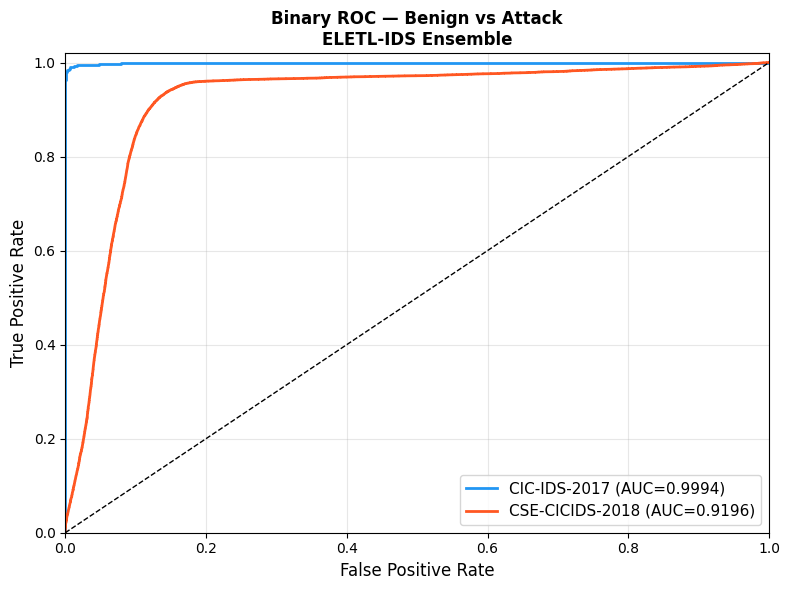

In [27]:
from sklearn.metrics import roc_curve, auc

fig, ax = plt.subplots(figsize=(8, 6))
benign_idx = list(class_names).index('Benign')

for dataset_name, y_bin_true, proba, color in [
    ('CIC-IDS-2017',    to_binary(y_test_2017,      class_names),
     results_2017['soft']['proba'], '#2196F3'),
    ('CSE-CICIDS-2018', to_binary(y_2018_remapped,  class_names),
     results_2018['soft']['proba'], '#FF5722'),
]:
    attack_proba = 1 - proba[:, benign_idx]
    fpr, tpr, _ = roc_curve(y_bin_true, attack_proba)
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, lw=2,
            label=f'{dataset_name} (AUC={roc_auc:.4f})')

ax.plot([0,1],[0,1],'k--', lw=1)
ax.set_xlim([0,1]); ax.set_ylim([0,1.02])
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('Binary ROC — Benign vs Attack\nELETL-IDS Ensemble', fontweight='bold')
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'binary_roc.png'), dpi=130, bbox_inches='tight')
plt.show()

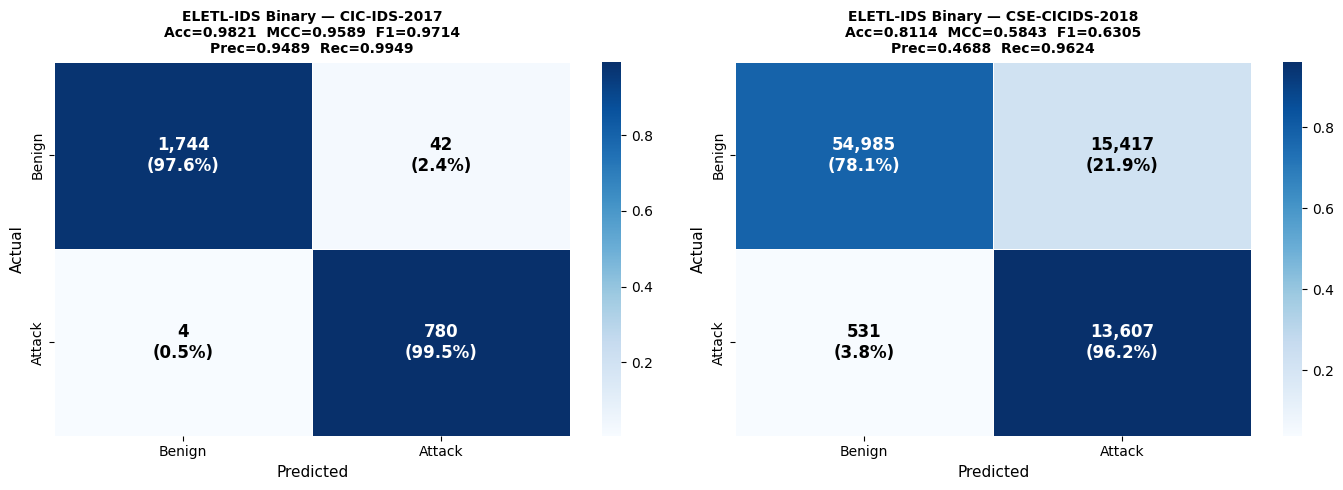

Saved → binary_cm.png


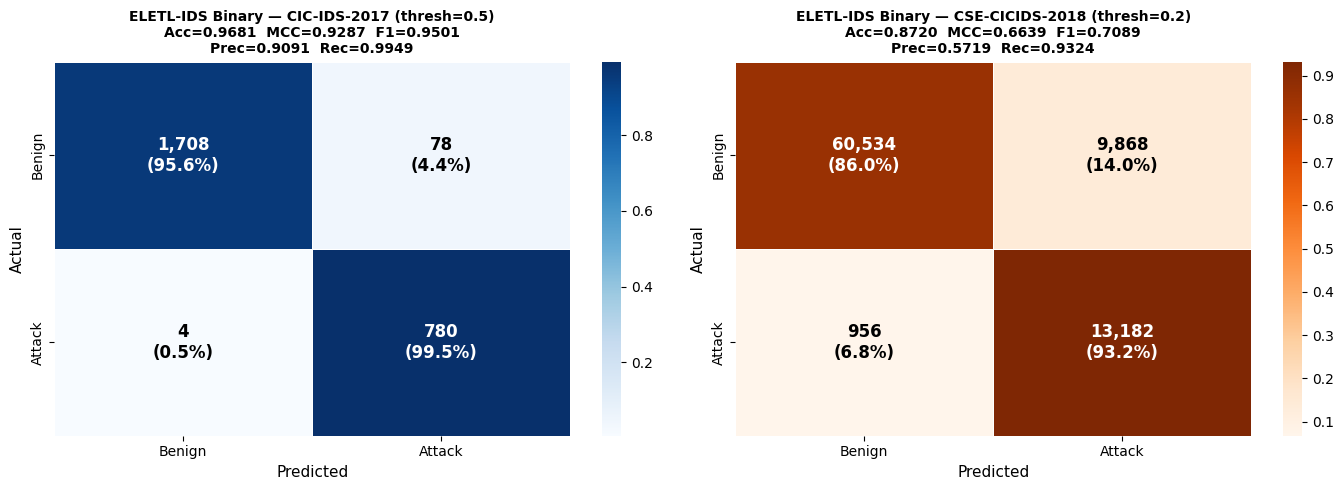

Saved → binary_cm_optimal_threshold.png


In [29]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (dataset_name, y_bin_true, results, y_true) in zip(axes, [
    ('CIC-IDS-2017',    y_bin_true_2017, results_2017, y_test_2017),
    ('CSE-CICIDS-2018', y_bin_true_2018, results_2018, y_2018_remapped),
]):
    y_bin_pred = to_binary(results['soft']['preds'], class_names)
    cm      = confusion_matrix(y_bin_true, y_bin_pred)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    sns.heatmap(cm_norm, ax=ax,
                xticklabels=['Benign', 'Attack'],
                yticklabels=['Benign', 'Attack'],
                cmap='Blues', annot=False,
                linewidths=0.5)

    # Annotate with both count and percentage
    for i in range(2):
        for j in range(2):
            ax.text(j + 0.5, i + 0.5,
                    f'{cm[i,j]:,}\n({cm_norm[i,j]*100:.1f}%)',
                    ha='center', va='center',
                    fontsize=12, fontweight='bold',
                    color='white' if cm_norm[i,j] > 0.5 else 'black')

    acc  = accuracy_score(y_bin_true, y_bin_pred)
    mcc  = matthews_corrcoef(y_bin_true, y_bin_pred)
    f1   = f1_score(y_bin_true, y_bin_pred, average='binary', zero_division=0)
    prec = precision_score(y_bin_true, y_bin_pred, average='binary', zero_division=0)
    rec  = recall_score(y_bin_true, y_bin_pred, average='binary', zero_division=0)

    ax.set_title(f'ELETL-IDS Binary — {dataset_name}\n'
                 f'Acc={acc:.4f}  MCC={mcc:.4f}  F1={f1:.4f}\n'
                 f'Prec={prec:.4f}  Rec={rec:.4f}',
                 fontweight='bold', fontsize=10)
    ax.set_xlabel('Predicted', fontsize=11)
    ax.set_ylabel('Actual',    fontsize=11)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'binary_cm.png'), dpi=130, bbox_inches='tight')
plt.show()
print('Saved → binary_cm.png')


# Also plot with optimal threshold (0.2) for 2018
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (dataset_name, y_bin_true, proba, thresh, color) in zip(axes, [
    ('CIC-IDS-2017 (thresh=0.5)',    y_bin_true_2017,
     results_2017['soft']['proba'], 0.5, 'Blues'),
    ('CSE-CICIDS-2018 (thresh=0.2)', y_bin_true_2018,
     results_2018['soft']['proba'], 0.2, 'Oranges'),
]):
    y_bin_pred = binary_from_proba(proba, class_names, threshold=thresh)
    cm      = confusion_matrix(y_bin_true, y_bin_pred)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    sns.heatmap(cm_norm, ax=ax,
                xticklabels=['Benign', 'Attack'],
                yticklabels=['Benign', 'Attack'],
                cmap=color, annot=False,
                linewidths=0.5)

    for i in range(2):
        for j in range(2):
            ax.text(j + 0.5, i + 0.5,
                    f'{cm[i,j]:,}\n({cm_norm[i,j]*100:.1f}%)',
                    ha='center', va='center',
                    fontsize=12, fontweight='bold',
                    color='white' if cm_norm[i,j] > 0.5 else 'black')

    acc  = accuracy_score(y_bin_true, y_bin_pred)
    mcc  = matthews_corrcoef(y_bin_true, y_bin_pred)
    f1   = f1_score(y_bin_true, y_bin_pred, average='binary', zero_division=0)
    prec = precision_score(y_bin_true, y_bin_pred, average='binary', zero_division=0)
    rec  = recall_score(y_bin_true, y_bin_pred, average='binary', zero_division=0)

    ax.set_title(f'ELETL-IDS Binary — {dataset_name}\n'
                 f'Acc={acc:.4f}  MCC={mcc:.4f}  F1={f1:.4f}\n'
                 f'Prec={prec:.4f}  Rec={rec:.4f}',
                 fontweight='bold', fontsize=10)
    ax.set_xlabel('Predicted', fontsize=11)
    ax.set_ylabel('Actual',    fontsize=11)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'binary_cm_optimal_threshold.png'),
            dpi=130, bbox_inches='tight')
plt.show()
print('Saved → binary_cm_optimal_threshold.png')

In [ ]:
from IPython.display import display
import pandas as pd

#  Multiclass results table
multiclass_rows = []
for name, info in results_2017['per_model'].items():
    multiclass_rows.append({
        'Model': name,
        'Dataset': 'CIC-IDS-2017',
        'Accuracy': f"{accuracy_score(y_test_2017, info['preds']):.4f}",
        'MCC':      f"{matthews_corrcoef(y_test_2017, info['preds']):.4f}",
        'Weighted F1': f"{f1_score(y_test_2017, info['preds'], average='weighted', zero_division=0):.4f}",
    })
multiclass_rows.append({
    'Model': 'ELETL-IDS (Ensemble)',
    'Dataset': 'CIC-IDS-2017',
    'Accuracy':    f"{accuracy_score(y_test_2017, results_2017['soft']['preds']):.4f}",
    'MCC':         f"{matthews_corrcoef(y_test_2017, results_2017['soft']['preds']):.4f}",
    'Weighted F1': f"{f1_score(y_test_2017, results_2017['soft']['preds'], average='weighted', zero_division=0):.4f}",
})

for name, info in results_2018['per_model'].items():
    multiclass_rows.append({
        'Model': name,
        'Dataset': 'CSE-CICIDS-2018',
        'Accuracy': f"{accuracy_score(y_2018_remapped, info['preds']):.4f}",
        'MCC':      f"{matthews_corrcoef(y_2018_remapped, info['preds']):.4f}",
        'Weighted F1': f"{f1_score(y_2018_remapped, info['preds'], average='weighted', zero_division=0):.4f}",
    })
multiclass_rows.append({
    'Model': 'ELETL-IDS (Ensemble)',
    'Dataset': 'CSE-CICIDS-2018',
    'Accuracy':    f"{accuracy_score(y_2018_remapped, results_2018['soft']['preds']):.4f}",
    'MCC':         f"{matthews_corrcoef(y_2018_remapped, results_2018['soft']['preds']):.4f}",
    'Weighted F1': f"{f1_score(y_2018_remapped, results_2018['soft']['preds'], average='weighted', zero_division=0):.4f}",
})

df_multi = pd.DataFrame(multiclass_rows)
print('\n📊 Multiclass Classification Results')
print('='*60)
display(df_multi.style
    .set_caption('Multiclass Results — CIC-IDS-2017 vs CSE-CICIDS-2018')
    .background_gradient(cmap='YlGn', subset=['Accuracy', 'MCC', 'Weighted F1'])
    .set_properties(**{'text-align': 'center'})
    .apply(lambda x: ['font-weight: bold' if x['Model'] == 'ELETL-IDS (Ensemble)'
                       else '' for _ in x], axis=1))

# Binary results table 
binary_rows = []
y_bin_true_2017 = to_binary(y_test_2017,     class_names)
y_bin_true_2018 = to_binary(y_2018_remapped, class_names)

for dataset_name, y_bin_true, results, y_true in [
    ('CIC-IDS-2017',    y_bin_true_2017, results_2017, y_test_2017),
    ('CSE-CICIDS-2018', y_bin_true_2018, results_2018, y_2018_remapped),
]:
    entries = (
        [(name, info['preds']) for name, info in results['per_model'].items()]
      + [('ELETL-IDS (Ensemble)', results['soft']['preds'])]
    )
    for name, preds in entries:
        y_bin_pred = to_binary(preds, class_names)
        binary_rows.append({
            'Model':      name,
            'Dataset':    dataset_name,
            'Accuracy':   f"{accuracy_score(y_bin_true, y_bin_pred):.4f}",
            'Precision':  f"{precision_score(y_bin_true, y_bin_pred, average='binary', zero_division=0):.4f}",
            'Recall':     f"{recall_score(y_bin_true, y_bin_pred, average='binary', zero_division=0):.4f}",
            'F1':         f"{f1_score(y_bin_true, y_bin_pred, average='binary', zero_division=0):.4f}",
            'MCC':        f"{matthews_corrcoef(y_bin_true, y_bin_pred):.4f}",
        })

df_binary = pd.DataFrame(binary_rows)
print('\n📊 Binary Classification Results (Benign vs Attack)')
print('='*60)
display(df_binary.style
    .set_caption('Binary Results — Benign vs Attack')
    .background_gradient(cmap='YlGn', subset=['Accuracy', 'Precision', 'Recall', 'F1', 'MCC'])
    .set_properties(**{'text-align': 'center'})
    .apply(lambda x: ['font-weight: bold' if x['Model'] == 'ELETL-IDS (Ensemble)'
                       else '' for _ in x], axis=1))

#  Threshold sweep table 
thresh_rows = []
for thresh in [0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]:
    y_bin_pred = binary_from_proba(results_2018['soft']['proba'], class_names, threshold=thresh)
    thresh_rows.append({
        'Threshold': thresh,
        'Accuracy':  f"{accuracy_score(y_bin_true_2018, y_bin_pred):.4f}",
        'Precision': f"{precision_score(y_bin_true_2018, y_bin_pred, average='binary', zero_division=0):.4f}",
        'Recall':    f"{recall_score(y_bin_true_2018, y_bin_pred, average='binary', zero_division=0):.4f}",
        'F1':        f"{f1_score(y_bin_true_2018, y_bin_pred, average='binary', zero_division=0):.4f}",
        'MCC':       f"{matthews_corrcoef(y_bin_true_2018, y_bin_pred):.4f}",
    })

df_thresh = pd.DataFrame(thresh_rows)
print('\n📊 Threshold Sweep — ELETL-IDS Binary on CSE-CICIDS-2018')
print('='*60)
display(df_thresh.style
    .set_caption('Threshold Sweep — Benign vs Attack on CSE-CICIDS-2018')
    .background_gradient(cmap='YlGn', subset=['Accuracy', 'Precision', 'Recall', 'F1', 'MCC'])
    .set_properties(**{'text-align': 'center'}))

# Save all tables
df_multi.to_csv(os.path.join(RESULTS_DIR,  'results_multiclass.csv'), index=False)
df_binary.to_csv(os.path.join(RESULTS_DIR, 'results_binary.csv'),     index=False)
df_thresh.to_csv(os.path.join(RESULTS_DIR, 'results_threshold.csv'),  index=False)
print('\nAll tables saved to results/ ✓')


📊 Multiclass Classification Results


,Model,Dataset,Accuracy,MCC,Weighted F1
0,InceptionV3,CIC-IDS-2017,0.9856,0.9719,0.9858
1,MobileNetV3Small,CIC-IDS-2017,0.9615,0.9294,0.9631
2,EfficientNetV2B0,CIC-IDS-2017,0.9381,0.8904,0.9414
3,ELETL-IDS (Ensemble),CIC-IDS-2017,0.9813,0.9640,0.9817
4,InceptionV3,CSE-CICIDS-2018,0.6457,0.2804,0.7125
5,MobileNetV3Small,CSE-CICIDS-2018,0.6904,0.2577,0.7488
6,EfficientNetV2B0,CSE-CICIDS-2018,0.3033,0.0741,0.4317
7,ELETL-IDS (Ensemble),CSE-CICIDS-2018,0.6692,0.2758,0.7323



📊 Binary Classification Results (Benign vs Attack)


,Model,Dataset,Accuracy,Precision,Recall,F1,MCC
0,InceptionV3,CIC-IDS-2017,0.9864,0.9641,0.9923,0.9780,0.9684
1,MobileNetV3Small,CIC-IDS-2017,0.9619,0.8907,0.9974,0.9410,0.9162
2,EfficientNetV2B0,CIC-IDS-2017,0.9412,0.8414,0.9949,0.9117,0.8750
3,ELETL-IDS (Ensemble),CIC-IDS-2017,0.9821,0.9489,0.9949,0.9714,0.9589
4,InceptionV3,CSE-CICIDS-2018,0.7786,0.4279,0.9612,0.5922,0.5418
5,MobileNetV3Small,CSE-CICIDS-2018,0.8346,0.5030,0.9139,0.6489,0.5944
6,EfficientNetV2B0,CSE-CICIDS-2018,0.4531,0.2317,0.9803,0.3748,0.2687
7,ELETL-IDS (Ensemble),CSE-CICIDS-2018,0.8114,0.4688,0.9624,0.6305,0.5843



📊 Threshold Sweep — ELETL-IDS Binary on CSE-CICIDS-2018


,Threshold,Accuracy,Precision,Recall,F1,MCC
0,0.200000,0.8720,0.5719,0.9324,0.7089,0.6639
1,0.300000,0.8472,0.5236,0.9564,0.6767,0.6332
2,0.400000,0.8021,0.4565,0.9619,0.6192,0.5718
3,0.500000,0.7306,0.3799,0.9657,0.5453,0.4900
4,0.600000,0.6152,0.2994,0.9709,0.4577,0.3855
5,0.700000,0.4439,0.2286,0.9790,0.3706,0.2611
6,0.800000,0.3273,0.1976,0.9873,0.3293,0.1834
7,0.900000,0.2303,0.1777,0.9934,0.3015,0.1064



All tables saved to results/ ✓


In [30]:
y_bin_pred_02 = binary_from_proba(
    results_2018['soft']['proba'], class_names, threshold=0.2)

acc  = accuracy_score(y_bin_true_2018,  y_bin_pred_02)
prec = precision_score(y_bin_true_2018, y_bin_pred_02, average='binary', zero_division=0)
rec  = recall_score(y_bin_true_2018,    y_bin_pred_02, average='binary', zero_division=0)
f1   = f1_score(y_bin_true_2018,        y_bin_pred_02, average='binary', zero_division=0)
mcc  = matthews_corrcoef(y_bin_true_2018, y_bin_pred_02)

df_02 = pd.DataFrame([{
    'Model'    : 'ELETL-IDS (Ensemble)',
    'Dataset'  : 'CSE-CICIDS-2018',
    'Threshold': 0.2,
    'Accuracy' : f'{acc:.4f}',
    'Precision': f'{prec:.4f}',
    'Recall'   : f'{rec:.4f}',
    'F1 Score' : f'{f1:.4f}',
    'MCC'      : f'{mcc:.4f}',
}])

display(df_02.style
    .set_caption('Binary Classification (Benign vs Attack) — CSE-CICIDS-2018 @ Threshold=0.2')
    .background_gradient(cmap='YlGn',
                         subset=['Accuracy','Precision','Recall','F1 Score','MCC'])
    .set_properties(**{'text-align': 'center'}))

df_02.to_csv(os.path.join(RESULTS_DIR, 'binary_results_2018_thresh02.csv'), index=False)
print('Saved ✓')

,Model,Dataset,Threshold,Accuracy,Precision,Recall,F1 Score,MCC
0,ELETL-IDS (Ensemble),CSE-CICIDS-2018,0.200000,0.8720,0.5719,0.9324,0.7089,0.6639


Saved ✓


In [31]:
y_bin_pred_02 = binary_from_proba(
    results_2018['soft']['proba'], class_names, threshold=0.2)

# Overall binary metrics
acc  = accuracy_score(y_bin_true_2018,  y_bin_pred_02)
prec = precision_score(y_bin_true_2018, y_bin_pred_02, average='binary', zero_division=0)
rec  = recall_score(y_bin_true_2018,    y_bin_pred_02, average='binary', zero_division=0)
f1   = f1_score(y_bin_true_2018,        y_bin_pred_02, average='binary', zero_division=0)
mcc  = matthews_corrcoef(y_bin_true_2018, y_bin_pred_02)

# Per-class (Benign and Attack separately)
report = classification_report(
    y_bin_true_2018, y_bin_pred_02,
    target_names=['Benign', 'Attack'],
    output_dict=True, zero_division=0)

rows = [
    {
        'Class'    : 'Overall (Binary)',
        'Accuracy' : f'{acc:.4f}',
        'Precision': f'{prec:.4f}',
        'Recall'   : f'{rec:.4f}',
        'F1 Score' : f'{f1:.4f}',
        'MCC'      : f'{mcc:.4f}',
    },
    {
        'Class'    : 'Benign',
        'Accuracy' : '—',
        'Precision': f"{report['Benign']['precision']:.4f}",
        'Recall'   : f"{report['Benign']['recall']:.4f}",
        'F1 Score' : f"{report['Benign']['f1-score']:.4f}",
        'MCC'      : '—',
    },
    {
        'Class'    : 'Attack (Malicious)',
        'Accuracy' : '—',
        'Precision': f"{report['Attack']['precision']:.4f}",
        'Recall'   : f"{report['Attack']['recall']:.4f}",
        'F1 Score' : f"{report['Attack']['f1-score']:.4f}",
        'MCC'      : '—',
    },
]

df_02 = pd.DataFrame(rows)

display(df_02.style
    .set_caption('Binary Classification (Benign vs Attack) — CSE-CICIDS-2018 @ Threshold=0.2')
    .background_gradient(cmap='YlGn',
                         subset=['Precision', 'Recall', 'F1 Score'])
    .set_properties(**{'text-align': 'center'})
    .apply(lambda x: ['font-weight: bold' if x['Class'] == 'Overall (Binary)'
                       else '' for _ in x], axis=1))

df_02.to_csv(os.path.join(RESULTS_DIR, 'binary_results_2018_thresh02.csv'), index=False)
print('Saved ✓')

,Class,Accuracy,Precision,Recall,F1 Score,MCC
0,Overall (Binary),0.8720,0.5719,0.9324,0.7089,0.6639
1,Benign,—,0.9845,0.8598,0.9179,—
2,Attack (Malicious),—,0.5719,0.9324,0.7089,—


Saved ✓
